# Two-Beam Intensity Calculations #

In [1]:
from pathlib import Path
REPO_ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "absorption_paper_source_data").is_dir())
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.optimize import curve_fit
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from scipy.integrate import quad

## Load Ug and Ug' For CsPbBr3 Orientation 1 ##

In [2]:
import pandas as pd, re
from pathlib import Path

K = 39.87
U_0_prime = 0.007202113881041598
csv_path = Path(str(REPO_ROOT / "absorption_paper_source_data/two_beam/filtered_cspbbr_1_Ug_values.csv"))
cif_path = str(REPO_ROOT / "diffBloch_version_0.0.1/data/cspbbr3/CsPbBr_P67-crot-050_dyn.cif_pets")
CIF_ORIENTATION = 1       # zone id to filter HKLs from CIF
G_MAX = 2.0                # Å⁻¹

def parse_hkl(s: str):
    return tuple(int(x.strip()) for x in s.strip().strip("()").split(","))

def hkls_3sigma(cif_file, zone_id):
    with open(cif_file) as f:
        lines = f.readlines()
    start = next(i for i,l in enumerate(lines) if l.strip().startswith("loop_") and "_refln_index_h" in "".join(lines[i+1:i+10]))
    headers, j = [], start+1
    while lines[j].strip().startswith("_refln"):
        headers.append(lines[j].strip()); j += 1
    data = []
    for l in lines[j:]:
        if re.match(r"^\s*[-0-9]", l):
            data.append(l.strip().split())
        else:
            break
    df = pd.DataFrame(data, columns=headers).apply(pd.to_numeric, errors="coerce")
    df = df[df["_refln_zone_axis_id"] == zone_id]
    mask = df["_refln_intensity_meas"] > 3 * df["_refln_intensity_sigma"]
    return {(int(h), int(k), int(l)) for h,k,l,m in zip(df["_refln_index_h"], df["_refln_index_k"], df["_refln_index_l"], mask) if m}

HKL_FILTER = hkls_3sigma(cif_path, CIF_ORIENTATION)

df = pd.read_csv(csv_path)
g_col = "g_length" if "g_length" in df.columns else "g_mag" if "g_mag" in df.columns else None
if g_col is None:
    raise ValueError("No |g| column found (expected 'g_length' or 'g_mag').")

beams = []
for _, row in df.iterrows():
    g_len = float(row[g_col])
    if g_len > G_MAX:
        continue
    hkl = parse_hkl(row["hkl"])
    if hkl not in HKL_FILTER:
        continue  # enforce 3σ filter
    U_g = float(f"{float(row['U_g_real']):.20f}")
    U_g_prime = float(f"{float(row['U_g_imag']):.20e}")
    if abs(U_g) > 0 and abs(U_g_prime) > 0:
        beams.append({"hkl": hkl, "U_g": U_g, "U_g_prime": U_g_prime})

beams_by_orientation = {"orientation_1": beams}

print(f"orientation_1 Beams (|g| <= {G_MAX} Å⁻¹, 3σ HKLs only):")
for b in beams_by_orientation["orientation_1"]:
    print(b)
print(f"Kept {len(beams)} of {len(df)} rows after filters; CIF 3σ HKLs: {len(HKL_FILTER)}")


orientation_1 Beams (|g| <= 2.0 Å⁻¹, 3σ HKLs only):
{'hkl': (2, -1, 2), 'U_g': 0.0120279822723394, 'U_g_prime': 0.0008849228456148}
{'hkl': (5, 9, -7), 'U_g': -0.0017412261957567, 'U_g_prime': -0.0003000754079407}
{'hkl': (7, 5, -2), 'U_g': -0.0085350461661405, 'U_g_prime': -0.0020675884015619}
{'hkl': (-5, -3, 1), 'U_g': -0.0046097968042853, 'U_g_prime': -0.00085349234197}
{'hkl': (-2, 1, -2), 'U_g': 0.0120279822723394, 'U_g_prime': 0.0008849228456148}
{'hkl': (-1, -5, 5), 'U_g': -0.005953699394237, 'U_g_prime': -0.0011575569653952}
{'hkl': (4, 0, 2), 'U_g': 0.0068993465512503, 'U_g_prime': 0.0011637160222228}
{'hkl': (3, 9, -8), 'U_g': -0.004012715085205, 'U_g_prime': -0.0013258321526988}
{'hkl': (4, -3, 5), 'U_g': -0.0091361385888939, 'U_g_prime': -0.0012550705637841}
{'hkl': (4, -2, 4), 'U_g': 0.0133941382336105, 'U_g_prime': 0.002795858730822}
{'hkl': (4, -1, 3), 'U_g': 0.01017476668477, 'U_g_prime': 0.001266073812935}
{'hkl': (6, -2, 5), 'U_g': -0.0007155017296987, 'U_g_prime': -

## Define relevant Two-Beam parameters ##

In [3]:

# Define functions for the parameters
def xi_0_prime(U_0_prime):
    return K / U_0_prime

def xi_g_prime(U_g_prime):
    return K / U_g_prime

def xi_g(U_g):
    return K / abs(U_g)

def kappa_0(U_0_prime):
    return np.pi / xi_0_prime(U_0_prime)

def delta_kappa(s, U_g_prime, U_g):
    x = xi_g(U_g) * s
    return np.pi / (xi_g_prime(U_g_prime) * np.sqrt(1 + x**2))

def delta_k(s, U_g):
    x = xi_g(U_g) * s
    return np.sqrt(1 + x**2) / xi_g(U_g)

# Define Psi_g^2 with absorption
def psi_squared_with_abs(s, t, U_g_prime, U_g, U_0_prime):
    x = xi_g(U_g) * s
    decay_factor = np.exp(-2 * kappa_0(U_0_prime) * t)  # Exponential decay factor
    cosh_term = np.cosh(2 * delta_kappa(s, U_g_prime, U_g) * t)  # Hyperbolic cosine term
    cos_term = np.cos(2 * np.pi * delta_k(s, U_g) * t)  # Cosine term
    numerator = cosh_term - cos_term
    denominator = 2 * (1 + x**2)  # Denominator
    return decay_factor * numerator / denominator

# Define Psi_g^2 without absorption
def psi_squared_without_abs(s, t, U_g):
    term = np.sqrt(s**2 + (1 / (xi_g(U_g)**2)))  # Argument of the sine function
    numerator = (np.sin(np.pi * t * term))**2  # Sine squared term
    denominator = (np.pi * term)**2  # Denominator term
    pre_factor = (np.pi / xi_g(U_g))**2  # Prefactor
    return pre_factor * numerator / denominator




In [4]:
import numpy as np
from scipy.integrate import quad
from tqdm import tqdm

# Thickness range
t_values = np.linspace(100, 2500, 121)  # Å

s_limit = 0.7          # fixed symmetric window in Å⁻¹
n_subintervals = 200   # split [-s_limit, s_limit] into this many parts

def integrate_with_splitting(func, args, s_min, s_max, n_parts=200):
    """Split integration range into n_parts and call quad on each subinterval."""
    s_grid = np.linspace(s_min, s_max, n_parts + 1)
    total = 0.0
    for a, b in zip(s_grid[:-1], s_grid[1:]):
        val, _ = quad(func, a, b, args=args, limit=50,
                      epsabs=1e-8, epsrel=1e-6)
        total += val
    return total

results_by_orientation = {}

for orientation, beams in beams_by_orientation.items():
    results_with_abs = []
    results_without_abs = []

    for beam in tqdm(beams, desc=f"Processing {orientation}", unit="beam"):
        U_g = beam["U_g"]
        U_g_prime = beam["U_g_prime"]

        integral_with_abs = []
        integral_without_abs = []

        for t in t_values:
            s_min, s_max = -s_limit, s_limit

            val_with = integrate_with_splitting(
                psi_squared_with_abs, (t, U_g_prime, U_g, U_0_prime),
                s_min, s_max, n_parts=n_subintervals
            )
            val_without = integrate_with_splitting(
                psi_squared_without_abs, (t, U_g),
                s_min, s_max, n_parts=n_subintervals
            )

            integral_with_abs.append(val_with)
            integral_without_abs.append(val_without)

        results_with_abs.append(integral_with_abs)
        results_without_abs.append(integral_without_abs)

    results_by_orientation[orientation] = {
        "beams": beams[:],
        "t_values": t_values,
        "with_abs": np.array(results_with_abs),
        "without_abs": np.array(results_without_abs),
    }


Processing orientation_1: 100%|██████████| 29/29 [02:40<00:00,  5.54s/beam]


In [5]:
import pandas as pd
from pathlib import Path

out_path = Path(str(REPO_ROOT / "absorption_paper_source_data/two_beam/two_beam_intensities_orientation1_filtered.csv"))

rows = []
for orientation, res in results_by_orientation.items():
    t_vals = res["t_values"]  # Å
    with_abs = res["with_abs"]      # shape: (n_beams, n_t)
    without_abs = res["without_abs"]
    beams = res["beams"]
    for b, I_with, I_no in zip(beams, with_abs, without_abs):
        h, k, l = b["hkl"]
        for t, iw, ino in zip(t_vals, I_with, I_no):
            rows.append({
                "orientation": orientation,
                "h": h, "k": k, "l": l,
                "thickness_A": t,
                "I_with_abs": iw,
                "I_without_abs": ino,
            })

df = pd.DataFrame(rows)

mode = "a" if out_path.exists() else "w"
header = not out_path.exists()

df.to_csv(out_path, mode=mode, header=header, index=False)
print(f"Wrote {len(df)} rows to {out_path} (mode='{mode}')")


Wrote 3509 rows to absorption_paper_source_data/two_beam/two_beam_intensities_orientation1_filtered.csv (mode='a')


In [6]:
import pandas as pd
import numpy as np

# -------------------------------
# Load stored METHOD-B Lorentz
# -------------------------------
df_L = pd.read_csv(str(REPO_ROOT / "absorption_paper_source_data/two_beam/lorentz_correction.csv"))
L_map = {(int(r.h), int(r.k), int(r.l)): float(r.L_factor)
         for _, r in df_L.iterrows()}

print("Loaded", len(L_map), "Lorentz values")

# -------------------------------
# Load the OLD intensity file
# -------------------------------
df = pd.read_csv(str(REPO_ROOT / "absorption_paper_source_data/two_beam/two_beam_intensities_orientation1_filtered.csv"))

# -------------------------------
# Apply METHOD-B Lorentz
# -------------------------------
new_L = []
new_I_with = []
new_I_no = []

for _, row in df.iterrows():
    hkl = (int(row.h), int(row.k), int(row.l))

    if hkl not in L_map:
        raise ValueError(f"HKL {hkl} missing in METHOD-B Lorentz file")

    L = L_map[hkl]

    new_L.append(L)
    new_I_with.append(row.I_with_abs * L)
    new_I_no.append(row.I_without_abs * L)

df["L_factor"] = new_L
df["I_with_abs"] = new_I_with
df["I_without_abs"] = new_I_no

# -------------------------------
# Save corrected intensities
# -------------------------------
out = "two_beam_intensities_orientation1_filtered_Lcorrected.csv"
df.to_csv(out, index=False)

print("Saved METHOD-B corrected file:", out)


Loaded 29 Lorentz values
Saved METHOD-B corrected file: two_beam_intensities_orientation1_filtered_Lcorrected.csv


In [7]:
import pandas as pd
import numpy as np
from pathlib import Path

def load_results_from_csv(csv_path: str):
    df = pd.read_csv(csv_path)
    results = {}
    for orientation, g in df.groupby("orientation"):
        # unique thicknesses in order
        t_vals = np.array(sorted(g["thickness_A"].unique()))
        # map HKL → row indices sorted by thickness
        hkls = g[["h", "k", "l"]].drop_duplicates().itertuples(index=False, name=None)
        beams = []
        with_abs_list = []
        without_abs_list = []
        for hkl in hkls:
            sub = g[(g["h"] == hkl[0]) & (g["k"] == hkl[1]) & (g["l"] == hkl[2])].sort_values("thickness_A")
            beams.append({"hkl": hkl})
            with_abs_list.append(sub["I_with_abs"].to_numpy())
            without_abs_list.append(sub["I_without_abs"].to_numpy())
        results[orientation] = {
            "beams": beams,
            "t_values": t_vals,
            "with_abs": np.array(with_abs_list),
            "without_abs": np.array(without_abs_list),
        }
    return results

# usage: rebuild results_by_orientation from your CSV
results_by_orientation = load_results_from_csv(str(REPO_ROOT / "absorption_paper_source_data/two_beam/two_beam_intensities_orientation1_filtered_Lcorrected.csv"))


/var/folders/c4/6p85bt0j36s30ymr87bddjkr0000gn/T/ipykernel_73944/1448562540.py:117: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.12, 0, 1, 1])


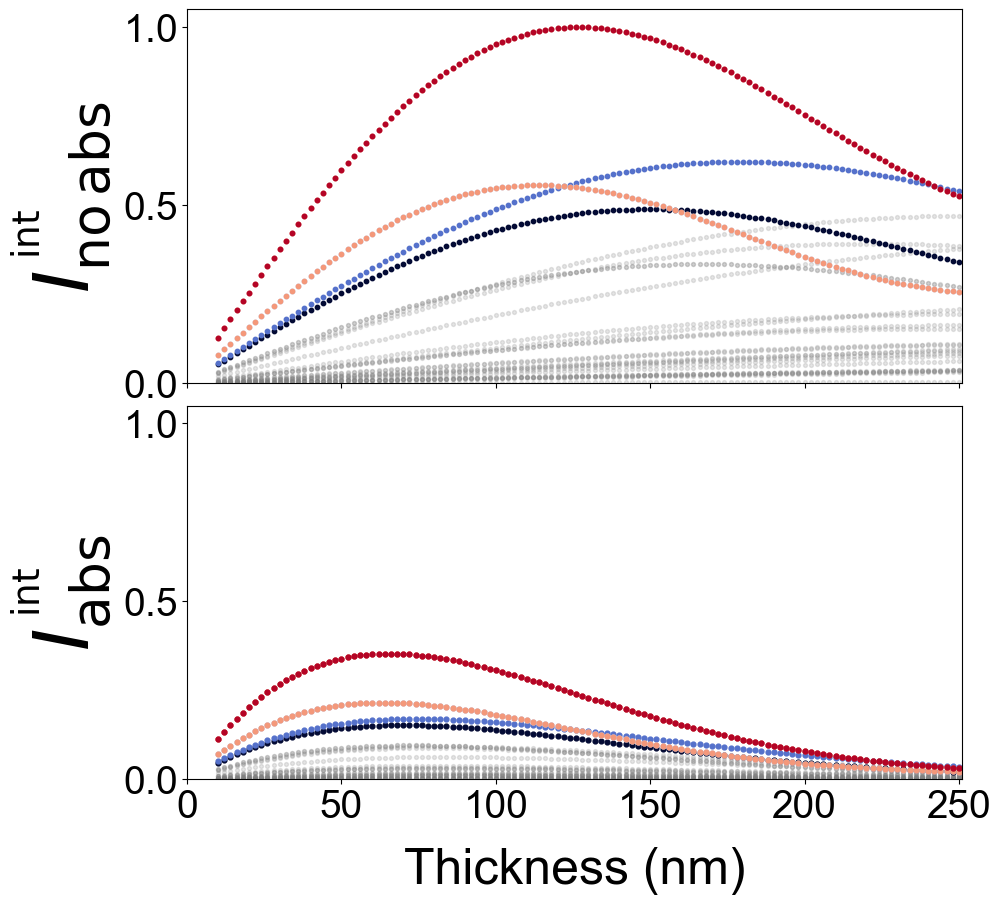

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter
from matplotlib.lines import Line2D

# =========================================================
# FORCE ARIAL FONT GLOBALLY
# =========================================================
plt.rcParams["font.family"] = "Arial"

def format_hkl_tex(h, k, l):
    """Return HKL string with proper overbars in TeX math mode."""
    def fmt(v):
        return r"\overline{%d}" % abs(v) if v < 0 else str(v)
    return f"$({fmt(h)}\,{fmt(k)}\,{fmt(l)})$"

selected_orientation = "orientation_1"

results_with_abs = results_by_orientation[selected_orientation]["with_abs"]
results_without_abs = results_by_orientation[selected_orientation]["without_abs"]
t_values = results_by_orientation[selected_orientation]["t_values"] / 10.0  # Å → nm
beams = results_by_orientation[selected_orientation]["beams"]

# --- HKLs of interest ---
hkls_to_plot = [
    (4,-2,4),
    (-4,2,-4),
    (-2,1,-2),
    (2,-1,2),
    (-7,-1,-2),
    (4,-1,3)
]

# --- Split beams ---
beams_rest = [(i, b) for i, b in enumerate(beams) if tuple(b["hkl"]) not in hkls_to_plot]

# --- Assign fixed colors in chosen order ---
hkls_ordered = [
    (-2,1,-2),(2,-1,2),
    (4,-2,4),(-4,2,-4),
    (7, 5, -2),
    (4,-1,3)
]
custom_colors = {
    (-2, 1, -2): "#b40426",
    (2, -1, 2):  "#dd5f4b",
    (4, -2, 4):  "#f4987a",
    (-4, 2, -4): "#b9d0f9",
    (7, 5, -2): "#5571cb",
    (4, -1, 3):  "#030a34",
}

# --- Global normalization ---
all_vals = np.concatenate([
    np.array(results_with_abs).flatten(),
    np.array(results_without_abs).flatten()
])
ymax = np.nanmax(all_vals)

# --- Figure ---
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(10, 10),
    sharex=True, gridspec_kw={'hspace': 0.06}
)

legend_labels = []

def setup_axis(ax, ylabel):
    ax.set_ylim(0, 1.05)
    ax.set_xlim(0, 251)
    ax.set_yticks([0, 0.5, 1.0])
    ax.tick_params(axis="both", which="major", labelsize=28)
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.yaxis.get_offset_text().set_fontsize(26)
    ax.set_ylabel(ylabel, fontsize=55, labelpad=5)

# --- Helper: mask values ---
mask = t_values >= 0

# --- Top: without absorption ---
for i, b in beams_rest:
    yvals = np.array(results_without_abs[i]) / ymax
    ax1.scatter(t_values[mask], yvals[mask], color="grey", s=8, alpha=0.2)

for hkl in reversed(hkls_ordered):
    idx = beams.index(next(b for b in beams if tuple(b["hkl"]) == hkl))
    yvals = np.array(results_without_abs[idx]) / ymax
    col = custom_colors[hkl]
    ax1.scatter(t_values[mask], yvals[mask], color=col, s=10, label=format_hkl_tex(*hkl))
    legend_labels.append(format_hkl_tex(*hkl))

setup_axis(ax1, r"$I_\mathrm{no\,abs}^{\;\!{}^{\mathrm{int}}}$")

# --- Bottom: with absorption ---
for i, b in beams_rest:
    yvals = np.array(results_with_abs[i]) / ymax
    ax2.scatter(t_values[mask], yvals[mask], color="grey", s=8, alpha=0.2)

for hkl in reversed(hkls_ordered):
    idx = beams.index(next(b for b in beams if tuple(b["hkl"]) == hkl))
    yvals = np.array(results_with_abs[idx]) / ymax
    col = custom_colors[hkl]
    ax2.scatter(t_values[mask], yvals[mask], color=col, s=12, label=format_hkl_tex(*hkl))

setup_axis(ax2, r"$I_\mathrm{abs}^{\;\!{}^{\mathrm{int}}}$")
ax2.set_xlabel(r"Thickness (nm)", fontsize=36, labelpad=15)

# --- Legend (big dots) ---
custom_handles = [
    Line2D([0], [0], marker='o', color='w', label=format_hkl_tex(*hkl),
           markerfacecolor=custom_colors[hkl], markersize=14)
    for hkl in hkls_ordered
]
custom_handles.append(Line2D([0], [0], marker='o', color='w',
                             label="Other HKLs", markerfacecolor="grey", alpha=0.9, markersize=14))

plt.tight_layout(rect=[0.12, 0, 1, 1])
plt.show()


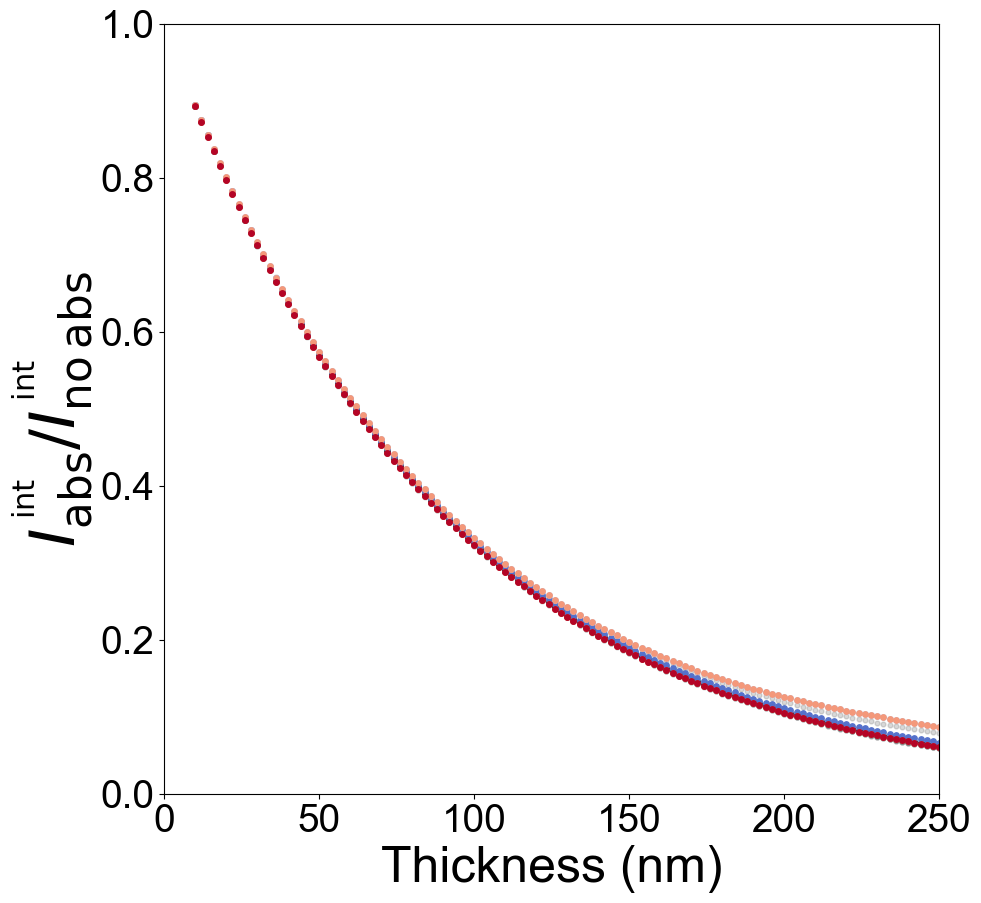

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# =========================================================
# FORCE ARIAL FONT GLOBALLY
# =========================================================
plt.rcParams["font.family"] = "Arial"

# --- HKL formatter ---
def format_hkl_tex(h, k, l):
    def fmt(v):
        return r"\overline{%d}" % abs(v) if v < 0 else str(v)
    return f"$({fmt(h)}\,{fmt(k)}\,{fmt(l)})$"

# --- Pick orientation ---
orientation_label = "orientation_1"
results = results_by_orientation[orientation_label]
results_with_abs = results["with_abs"]
results_without_abs = results["without_abs"]
t_values = results["t_values"] / 10.0  # Å → nm
beams = results["beams"]

# -------------------------------------------------------------------
# Colors
# -------------------------------------------------------------------
custom_colors = {
    (-2, 1, -2): "#b40426",
    (2, -1, 2):  "#dd5f4b",
    (4, -2, 4):  "#f4987a",
    (-4, 2, -4): "#b9d0f9",
    (7, 5, -2): "#5571cb",
    (4, -1, 3):  "#030a34",
}
hkls_ordered = list(custom_colors.keys())

plt.figure(figsize=(10, 10))

lambdas = []

# ===================================================================
# 1) GREY HKLs FIRST
# ===================================================================
for beam, with_vals, without_vals in zip(beams, results_with_abs, results_without_abs):

    hkl = tuple(beam["hkl"])
    if hkl in custom_colors:
        continue

    ratio = np.divide(
        with_vals, without_vals,
        out=np.full_like(with_vals, np.nan, dtype=float),
        where=(np.array(without_vals) != 0)
    )

    valid = ~np.isnan(ratio)
    if not np.any(valid):
        continue

    t_clean = t_values[valid]
    r_clean = np.array(ratio)[valid]

    if len(r_clean) > 1:
        log_r = np.log(r_clean)
        m, _, _, _ = np.linalg.lstsq(t_clean.reshape(-1,1), log_r, rcond=None)
        lam = -1.0 / m[0]
        lambdas.append(lam)

    plt.scatter(t_clean, r_clean, color="grey", s=12, alpha=0.3)

# ===================================================================
# 2) COLORED HKLs IN REVERSE ORDER
# ===================================================================
for hkl in reversed(hkls_ordered):

    idx = [tuple(b["hkl"]) for b in beams].index(hkl)

    with_vals = results_with_abs[idx]
    without_vals = results_without_abs[idx]

    ratio = np.divide(
        with_vals, without_vals,
        out=np.full_like(with_vals, np.nan, dtype=float),
        where=(np.array(without_vals) != 0)
    )
    valid = ~np.isnan(ratio)
    t_clean = t_values[valid]
    r_clean = np.array(ratio)[valid]

    if len(r_clean) > 1:
        log_r = np.log(r_clean)
        m, _, _, _ = np.linalg.lstsq(t_clean.reshape(-1,1), log_r, rcond=None)
        lam = -1.0 / m[0]
        lambdas.append(lam)

    plt.scatter(t_clean, r_clean,
                color=custom_colors[hkl], s=15,
                label=format_hkl_tex(*hkl))

# ===================================================================
# Stats label
# ===================================================================
if len(lambdas):
    lam_mean = np.mean(lambdas)
    lam_std = np.std(lambdas)
    stats_label = (
        r"$y = e^{-t/\lambda}$" + "\n" +
        fr"$\bar\lambda = {lam_mean:.1f}\,\mathrm{{nm}}$" + "\n" +
        fr"$\sigma_\lambda = {lam_std:.1f}\,\mathrm{{nm}}$"
    )
else:
    stats_label = r"No valid $\lambda$ fits"

# ===================================================================
# Legend
# ===================================================================
legend_handles = [Line2D([0], [0], color="white", label=stats_label)]
legend_labels = [stats_label] + \
                [format_hkl_tex(*hkl) for hkl in hkls_ordered] + ["Other"]

#leg = plt.legend(
#    legend_handles, legend_labels,
#    fontsize=23,
#    loc="upper right",
#    frameon=True,
#    ncol=1,
#    handletextpad=-1,
#    handlelength=1.5,
#    borderaxespad=0.1
#)

#for i, text in enumerate(leg.get_texts()):
#    if i == 0:
#        text.set_fontsize(30); text.set_ha("left")
#    else:
#        text.set_fontsize(24); text.set_ha("left"); text.set_position((55, 0))

# ===================================================================
# Axes
# ===================================================================
plt.xlabel("Thickness (nm)", fontsize=36)
plt.ylabel(r"$I_\mathrm{abs}^{\;\!{}^{\mathrm{int}}} / I_\mathrm{no\,abs}^{\;\!{}^{\mathrm{int}}}$", fontsize=45)

plt.xlim(0, 100)
plt.ylim(0, 1)

plt.xticks([0, 50, 100, 150, 200, 250])
plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

plt.tick_params(axis='both', which='major', labelsize=28)
plt.tick_params(axis='both', which='minor', labelsize=28)

plt.show()


# Compare Analytical Integrated Absorption Expression to Numerical Result #

In [10]:
import numpy as np
from scipy.integrate import quad
from tqdm import tqdm

# Thickness range
t_values = np.linspace(100, 3500, 250)  # Å

s_limit = 0.7          # fixed symmetric window in Å⁻¹
n_subintervals = 200   # split [-s_limit, s_limit] into this many parts

def integrate_with_splitting(func, args, s_min, s_max, n_parts=200):
    """Split integration range into n_parts and call quad on each subinterval."""
    s_grid = np.linspace(s_min, s_max, n_parts + 1)
    total = 0.0
    for a, b in zip(s_grid[:-1], s_grid[1:]):
        val, _ = quad(func, a, b, args=args, limit=50,
                      epsabs=1e-8, epsrel=1e-6)
        total += val
    return total

results_by_orientation = {}

for orientation, beams in beams_by_orientation.items():
    results_with_abs = []
    results_without_abs = []

    for beam in tqdm(beams, desc=f"Processing {orientation}", unit="beam"):
        U_g = beam["U_g"]
        U_g_prime = beam["U_g_prime"]

        integral_with_abs = []
        integral_without_abs = []

        for t in t_values:
            s_min, s_max = -s_limit, s_limit

            val_with = integrate_with_splitting(
                psi_squared_with_abs, (t, U_g_prime, U_g, U_0_prime),
                s_min, s_max, n_parts=n_subintervals
            )
            val_without = integrate_with_splitting(
                psi_squared_without_abs, (t, U_g),
                s_min, s_max, n_parts=n_subintervals
            )

            integral_with_abs.append(val_with)
            integral_without_abs.append(val_without)

        results_with_abs.append(integral_with_abs)
        results_without_abs.append(integral_without_abs)

    results_by_orientation[orientation] = {
        "beams": beams[:],
        "t_values": t_values,
        "with_abs": np.array(results_with_abs),
        "without_abs": np.array(results_without_abs),
    }


Processing orientation_1: 100%|██████████| 29/29 [06:05<00:00, 12.60s/beam]


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# -------------------------------------------------------------------
# FORMATTER
# -------------------------------------------------------------------
def format_hkl_tex(h, k, l):
    def fmt(v):
        return r"\overline{%d}" % abs(v) if v < 0 else str(v)
    return f"$({fmt(h)}\,{fmt(k)}\,{fmt(l)})$"

# -------------------------------------------------------------------
# Thickness arrays
# -------------------------------------------------------------------
t_nm = t_values / 10.0       # nm for plotting
t = t_values                 # Å for analytic expressions

# -------------------------------------------------------------------
# CONSTANTS
# -------------------------------------------------------------------
kappa0 = kappa_0(U_0_prime)

# -------------------------------------------------------------------
# EXPONENTIAL FIT MODEL
# -------------------------------------------------------------------
def neg_exp(t, lam):
    return np.exp(-t / lam)

# -------------------------------------------------------------------
# ANALYTIC FULL EXPRESSION
# -------------------------------------------------------------------
def F_theory_full(t, U_g, U_g_prime):
    xi_g_val  = xi_g(U_g)
    xi_gp_val = xi_g_prime(U_g_prime)

    A = np.pi * t / xi_g_val
    absorptive = (np.pi**3 * t**2) / (2 * xi_gp_val**2)
    elastic = A - (A**3)/12.0
    ratio = absorptive / elastic

    return np.exp(-2 * kappa0 * t) * (1.0 + ratio)

# -------------------------------------------------------------------
# COLORS
# -------------------------------------------------------------------
custom_colors = {
    (-2, 1, -2): "#b40426",
    (2, -1, 2):  "#dd5f4b",
    (4, -2, 4):  "#f4987a",
    (-4, 2, -4): "#b9d0f9",
    (-7, -1, -2): "#5571cb",
    (4, -1, 3):  "#030a34",
}
hkls_ordered = list(custom_colors.keys())

# -------------------------------------------------------------------
# LOAD VALUES
# -------------------------------------------------------------------
orientation = "orientation_1"
results = results_by_orientation[orientation]
with_abs = results["with_abs"]
without_abs = results["without_abs"]
beams = results["beams"]

lambda_numeric = []
lambda_analytic = []


In [12]:
# ================================================================
# SHARED SETUP USED BY ALL FIGURES
# ================================================================

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams["font.family"] = "Arial"


# ------------------------------------------------
# Display HKLs nicely in the legend
# ------------------------------------------------
def format_hkl_tex(h, k, l):
    def fmt(v):
        return r"\overline{%d}" % abs(v) if v < 0 else str(v)

    return f"$({fmt(h)}\,{fmt(k)}\,{fmt(l)})$"


# ------------------------------------------------
# Fit y = exp(-t/lambda) in log space
# ------------------------------------------------
def fit_lambda_logspace(tvals, rvals):
    valid = np.isfinite(rvals) & (rvals > 0)

    if np.count_nonzero(valid) < 2:
        return np.nan

    log_r = np.log(rvals[valid])
    m, _, _, _ = np.linalg.lstsq(
        tvals[valid].reshape(-1, 1),
        log_r,
        rcond=None
    )

    return -1.0 / m[0]


# ------------------------------------------------
# Load numerical and analytical beam data
# ------------------------------------------------
orientation = "orientation_1"
results = results_by_orientation[orientation]

with_abs = results["with_abs"]
without_abs = results["without_abs"]

t = np.asarray(results["t_values"], dtype=float)       # Angstrom
t_nm = t / 10.0                                        # nm

beams = results["beams"]
beam_hkls = [tuple(b["hkl"]) for b in beams]

analytic_beams = beams_by_orientation[orientation]
analytic_hkls = [tuple(b["hkl"]) for b in analytic_beams]


# ------------------------------------------------
# HKLs to highlight
# ------------------------------------------------
custom_colors_requested = {
    (-2, 1, -2): "#b40426",
    (2, -1, 2):  "#dd5f4b",
    (4, -2, 4):  "#f4987a",
    (-4, 2, -4): "#b9d0f9",
    (7, 5, -2):  "#5571cb",
    (4, -1, 3):  "#030a34",
    (-7, -1, -2): "#2ca02c",
}

custom_colors = {
    hkl: col
    for hkl, col in custom_colors_requested.items()
    if hkl in beam_hkls and hkl in analytic_hkls
}

hkls_ordered = list(custom_colors.keys())

missing = [
    hkl for hkl in custom_colors_requested
    if hkl not in beam_hkls or hkl not in analytic_hkls
]

print("Highlighted HKLs:")
for hkl in hkls_ordered:
    print(hkl)

if missing:
    print("Skipped missing HKLs:", missing)


# ------------------------------------------------
# Shared plot styling
# ------------------------------------------------
s_main = 5
s_inset = 20

x_min, x_max = 0, 350
y_min, y_max = 0, 1

rect_x0, rect_x1 = 250, 350
rect_y0, rect_y1 = 0, 0.12

title_fs = 40
label_fs = 40
ylabel_fs = 55
tick_fs = 34
legend_fs = 32
global_legend_fs = 34

Highlighted HKLs:
(-2, 1, -2)
(2, -1, 2)
(4, -2, 4)
(-4, 2, -4)
(7, 5, -2)
(4, -1, 3)
(-7, -1, -2)


/var/folders/c4/6p85bt0j36s30ymr87bddjkr0000gn/T/ipykernel_73944/1570910854.py:409: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Highlighted HKLs:
(-2, 1, -2)
(2, -1, 2)
(4, -2, 4)
(-4, 2, -4)
(7, 5, -2)
(4, -1, 3)
(-7, -1, -2)


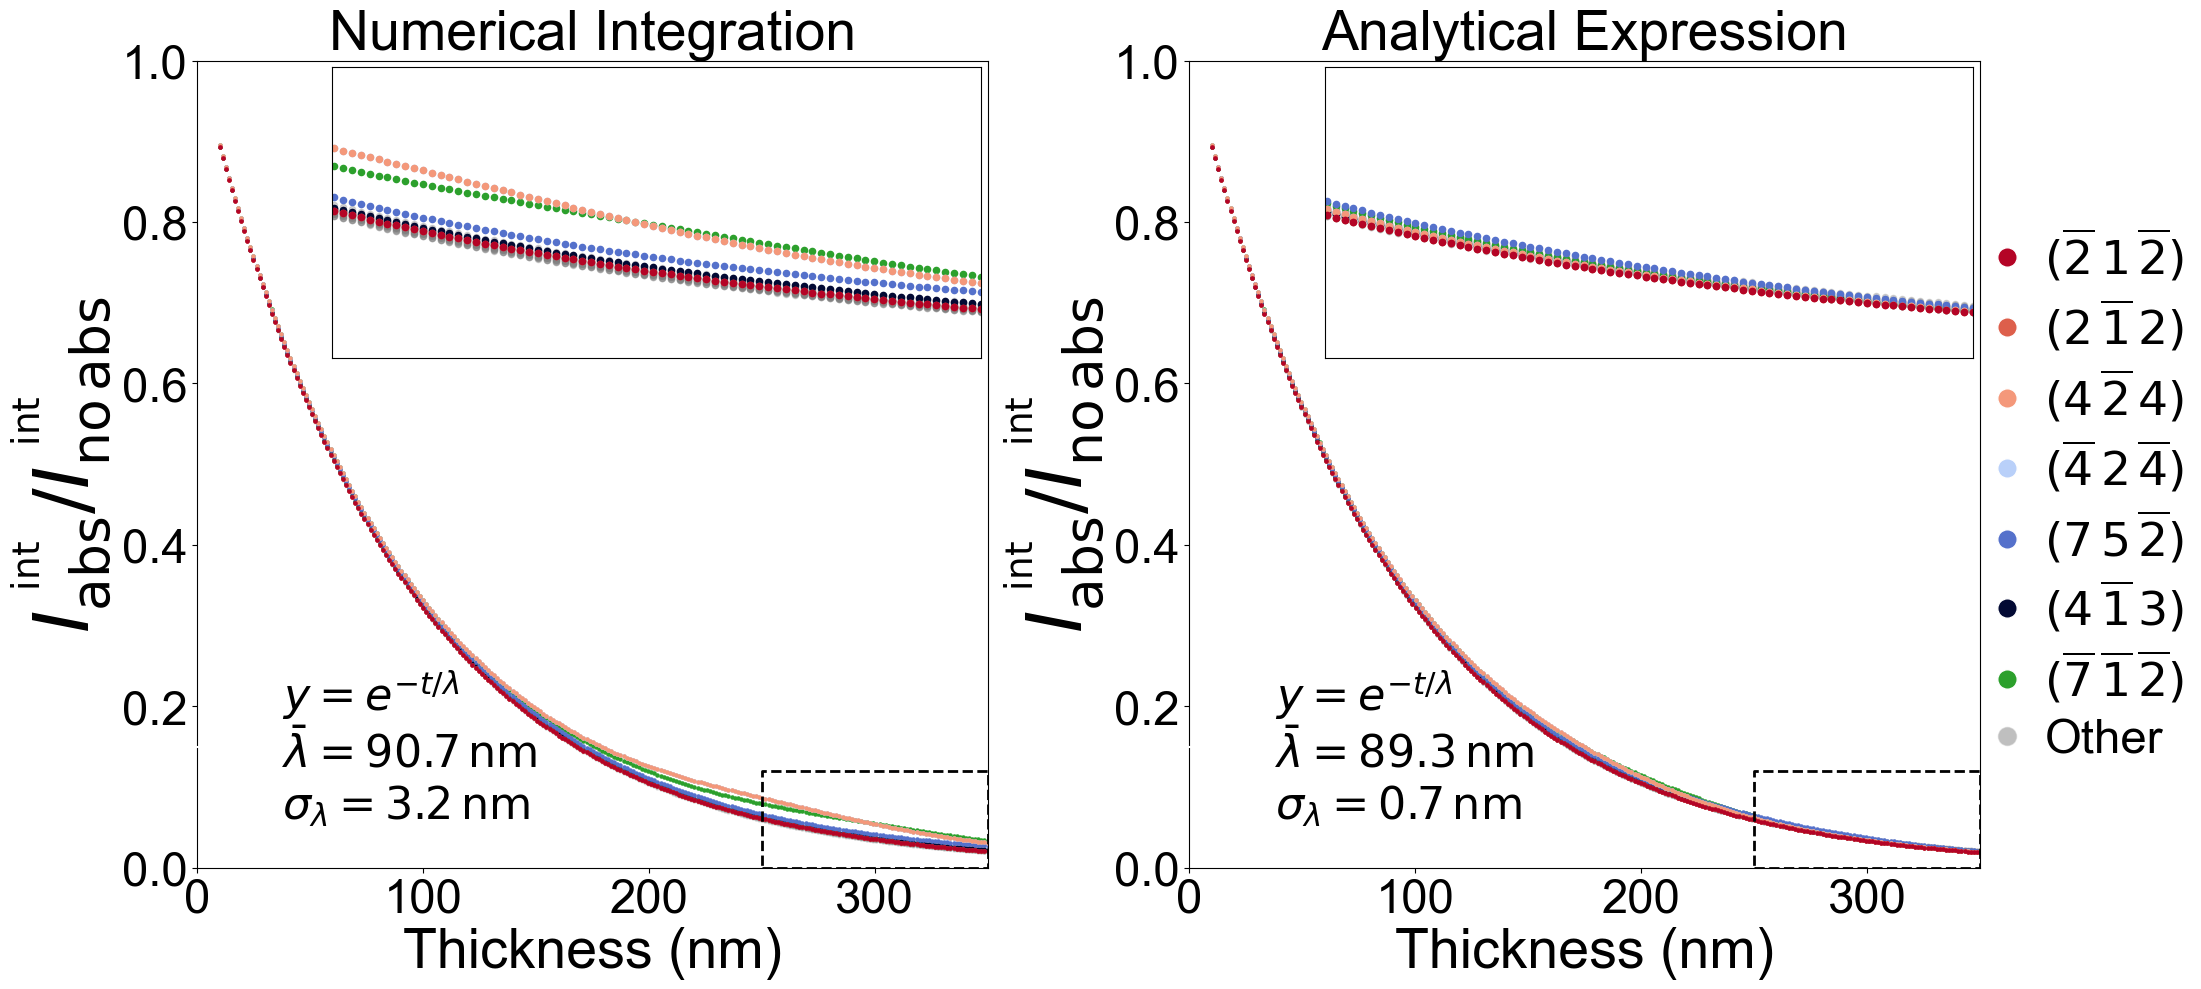

Numerical HKLs fitted: 29
Analytic HKLs fitted: 29


In [13]:
# -------------------------------------------------------------------
# FULL FIGURE CELL WITH CLOSED-FORM ANALYTIC EXPRESSION
# No integrals, no J0, no quad
#
# Analytical panel plots:
# exp(-2 kappa0 t) *
# [1 + (pi^2 t xi_g)/(4 xi_g'^2)
#      * (1 - A^2/3 + A^4/20)^(-1)]
#
# where A = pi t / xi_g
# -------------------------------------------------------------------

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams["font.family"] = "Arial"


def format_hkl_tex(h, k, l):
    def fmt(v):
        return r"\overline{%d}" % abs(v) if v < 0 else str(v)
    return f"$({fmt(h)}\,{fmt(k)}\,{fmt(l)})$"


def fit_lambda_logspace(tvals, rvals):
    valid = np.isfinite(rvals) & (rvals > 0)

    if np.count_nonzero(valid) < 2:
        return np.nan

    log_r = np.log(rvals[valid])
    m, _, _, _ = np.linalg.lstsq(tvals[valid].reshape(-1, 1), log_r, rcond=None)

    return -1.0 / m[0]


def F_theory_A14_nextterm(t, U_g, U_g_prime):
    t = np.asarray(t, dtype=float)

    xi_g_val = xi_g(U_g)
    xi_gp_val = xi_g_prime(U_g_prime)

    A = np.pi * t / xi_g_val

    denominator = (
        1.0
        - A**2 / 3.0
        + A**4 / 20.0
    )

    correction = (
        (np.pi * t * xi_g_val)
        / (2.0 * xi_gp_val**2)
        * denominator**(-1)
    )

    return np.exp(-2.0 * kappa_0(U_0_prime) * t) * (1.0 + correction)


# -------------------------------------------------------------------
# Make sure required arrays exist
# -------------------------------------------------------------------

orientation = "orientation_1"
results = results_by_orientation[orientation]

with_abs = results["with_abs"]
without_abs = results["without_abs"]
t_nm = np.asarray(results["t_values"], dtype=float) / 10.0
t = np.asarray(results["t_values"], dtype=float)
beams = results["beams"]

beam_hkls = [tuple(b["hkl"]) for b in beams]

analytic_beams = beams_by_orientation[orientation]
analytic_hkls = [tuple(b["hkl"]) for b in analytic_beams]


# -------------------------------------------------------------------
# Highlighted HKLs
# -------------------------------------------------------------------

custom_colors_requested = {
    (-2, 1, -2): "#b40426",
    (2, -1, 2):  "#dd5f4b",
    (4, -2, 4):  "#f4987a",
    (-4, 2, -4): "#b9d0f9",
    (7, 5, -2):  "#5571cb",
    (4, -1, 3):  "#030a34",
    (-7, -1, -2): "#2ca02c",
}

custom_colors = {
    hkl: col
    for hkl, col in custom_colors_requested.items()
    if hkl in beam_hkls and hkl in analytic_hkls
}

hkls_ordered = list(custom_colors.keys())

print("Highlighted HKLs:")
for hkl in hkls_ordered:
    print(hkl)

missing = [
    hkl for hkl in custom_colors_requested
    if hkl not in beam_hkls or hkl not in analytic_hkls
]

if missing:
    print("Skipped missing HKLs:", missing)


lambda_numeric = []
lambda_analytic = []

fig, axes = plt.subplots(1, 2, figsize=(20, 10))

s_main = 5
s_inset = 20

rect_x0, rect_x1 = 250, 350
rect_y0, rect_y1 = 0, 0.12


# ===================================================================
# PANEL 1 — NUMERICAL
# ===================================================================

ax = axes[0]

grey_scatter_x = []
grey_scatter_y = []
count_numeric = 0

for beam, num_with, num_without in zip(beams, with_abs, without_abs):
    hkl = tuple(beam["hkl"])

    num_with = np.asarray(num_with, dtype=float)
    num_without = np.asarray(num_without, dtype=float)

    r = np.divide(
        num_with,
        num_without,
        out=np.full_like(num_with, np.nan, dtype=float),
        where=(num_without != 0)
    )

    valid = np.isfinite(r) & (r > 0)

    if not np.any(valid):
        continue

    if hkl not in custom_colors:
        grey_scatter_x.append(t_nm[valid])
        grey_scatter_y.append(r[valid])
        ax.scatter(t_nm[valid], r[valid], color="grey", s=s_main, alpha=0.1)
        lambda_numeric.append(fit_lambda_logspace(t_nm[valid], r[valid]))
        count_numeric += 1

for hkl in reversed(hkls_ordered):
    idx = beam_hkls.index(hkl)

    num_with_arr = np.asarray(with_abs[idx], dtype=float)
    num_without_arr = np.asarray(without_abs[idx], dtype=float)

    r = np.divide(
        num_with_arr,
        num_without_arr,
        out=np.full_like(num_with_arr, np.nan, dtype=float),
        where=(num_without_arr != 0)
    )

    valid = np.isfinite(r) & (r > 0)

    if not np.any(valid):
        continue

    ax.scatter(t_nm[valid], r[valid], color=custom_colors[hkl], s=s_main)
    lambda_numeric.append(fit_lambda_logspace(t_nm[valid], r[valid]))
    count_numeric += 1

ax.set_title("Numerical Integration", fontsize=40)
ax.set_xlabel("Thickness (nm)", fontsize=40)
ax.set_ylabel(
    r"$I_\mathrm{abs}^{\;{}^{\mathrm{int}}}/I_\mathrm{no\,abs}^{\;{}^{\mathrm{int}}}$",
    fontsize=55
)
ax.set_xlim(0, 350)
ax.set_ylim(0, 1)
ax.tick_params(axis="both", which="major", labelsize=34)

ax.plot(
    [rect_x0, rect_x1, rect_x1, rect_x0, rect_x0],
    [rect_y0, rect_y0, rect_y1, rect_y1, rect_y0],
    linestyle="--",
    color="black",
    linewidth=2
)

lambda_numeric = np.asarray(lambda_numeric, dtype=float)
lambda_numeric = lambda_numeric[np.isfinite(lambda_numeric)]

if lambda_numeric.size:
    lam_mu = np.mean(lambda_numeric)
    lam_sd = np.std(lambda_numeric)

    eq_text = (
        r"$y = e^{-t/\lambda}$" + "\n" +
        fr"$\bar\lambda = {lam_mu:.1f}\,\mathrm{{nm}}$" + "\n" +
        fr"$\sigma_\lambda = {lam_sd:.1f}\,\mathrm{{nm}}$"
    )

    ax.legend(
        [Line2D([0], [0], color="white", label=eq_text)],
        [eq_text],
        fontsize=32,
        loc="lower left",
        frameon=False,
        bbox_to_anchor=(-0.1, 0.00)
    )

in_ax = inset_axes(ax, width="82%", height="36%", loc="upper right")
in_ax.set_xlim(rect_x0, rect_x1)
in_ax.set_ylim(rect_y0, rect_y1)

for xvals, yvals in zip(grey_scatter_x, grey_scatter_y):
    in_ax.scatter(xvals, yvals, color="grey", s=s_inset, alpha=0.3)

for hkl in reversed(hkls_ordered):
    idx = beam_hkls.index(hkl)

    num_with_arr = np.asarray(with_abs[idx], dtype=float)
    num_without_arr = np.asarray(without_abs[idx], dtype=float)

    r = np.divide(
        num_with_arr,
        num_without_arr,
        out=np.full_like(num_with_arr, np.nan, dtype=float),
        where=(num_without_arr != 0)
    )

    valid = np.isfinite(r) & (r > 0)

    if np.any(valid):
        in_ax.scatter(t_nm[valid], r[valid], color=custom_colors[hkl], s=s_inset)

in_ax.set_xticks([])
in_ax.set_yticks([])


# ===================================================================
# PANEL 2 — ANALYTICAL CLOSED-FORM EXPRESSION
# ===================================================================

ax = axes[1]

grey_scatter_x = []
grey_scatter_y = []
count_analytic = 0

for beam in analytic_beams:
    hkl = tuple(beam["hkl"])

    F_vals = np.asarray(
        F_theory_A14_nextterm(t, beam["U_g"], beam["U_g_prime"]),
        dtype=float
    )

    valid = np.isfinite(F_vals) & (F_vals > 0)

    if not np.any(valid):
        continue

    if hkl not in custom_colors:
        grey_scatter_x.append(t_nm[valid])
        grey_scatter_y.append(F_vals[valid])
        ax.scatter(t_nm[valid], F_vals[valid], color="grey", s=s_main, alpha=0.3)
        lambda_analytic.append(fit_lambda_logspace(t_nm[valid], F_vals[valid]))
        count_analytic += 1

for hkl in reversed(hkls_ordered):
    beam = analytic_beams[analytic_hkls.index(hkl)]

    F_vals = np.asarray(
        F_theory_A14_nextterm(t, beam["U_g"], beam["U_g_prime"]),
        dtype=float
    )

    valid = np.isfinite(F_vals) & (F_vals > 0)

    if not np.any(valid):
        continue

    ax.scatter(t_nm[valid], F_vals[valid], color=custom_colors[hkl], s=s_main)
    lambda_analytic.append(fit_lambda_logspace(t_nm[valid], F_vals[valid]))
    count_analytic += 1

ax.set_title("Analytical Expression", fontsize=40)
ax.set_xlabel("Thickness (nm)", fontsize=40)
ax.set_ylabel(
    r"$I_\mathrm{abs}^{\;{}^{\mathrm{int}}}/I_\mathrm{no\,abs}^{\;{}^{\mathrm{int}}}$",
    fontsize=55
)
ax.set_xlim(0, 350)
ax.set_ylim(0, 1)
ax.tick_params(axis="both", which="major", labelsize=34)

ax.plot(
    [rect_x0, rect_x1, rect_x1, rect_x0, rect_x0],
    [rect_y0, rect_y0, rect_y1, rect_y1, rect_y0],
    linestyle="--",
    color="black",
    linewidth=2
)

lambda_analytic = np.asarray(lambda_analytic, dtype=float)
lambda_analytic = lambda_analytic[np.isfinite(lambda_analytic)]

if lambda_analytic.size:
    lam_mu = np.mean(lambda_analytic)
    lam_sd = np.std(lambda_analytic)

    eq_text = (
        r"$y = e^{-t/\lambda}$" + "\n" +
        fr"$\bar\lambda = {lam_mu:.1f}\,\mathrm{{nm}}$" + "\n" +
        fr"$\sigma_\lambda = {lam_sd:.1f}\,\mathrm{{nm}}$"
    )

    ax.legend(
        [Line2D([0], [0], color="white", label=eq_text)],
        [eq_text],
        fontsize=32,
        loc="lower left",
        frameon=False,
        bbox_to_anchor=(-0.1, 0.00)
    )

in_ax = inset_axes(ax, width="82%", height="36%", loc="upper right")
in_ax.set_xlim(rect_x0, rect_x1)
in_ax.set_ylim(rect_y0, rect_y1)

for xvals, yvals in zip(grey_scatter_x, grey_scatter_y):
    in_ax.scatter(xvals, yvals, color="grey", s=s_inset, alpha=0.3)

for hkl in reversed(hkls_ordered):
    beam = analytic_beams[analytic_hkls.index(hkl)]

    F_vals = np.asarray(
        F_theory_A14_nextterm(t, beam["U_g"], beam["U_g_prime"]),
        dtype=float
    )

    valid = np.isfinite(F_vals) & (F_vals > 0)

    if np.any(valid):
        in_ax.scatter(t_nm[valid], F_vals[valid], color=custom_colors[hkl], s=s_inset)

in_ax.set_xticks([])
in_ax.set_yticks([])


# ===================================================================
# GLOBAL LEGEND
# ===================================================================

legend_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=custom_colors[hkl],
        markersize=14
    )
    for hkl in hkls_ordered
]

legend_labels = [format_hkl_tex(*hkl) for hkl in hkls_ordered]

legend_handles.append(
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor="grey",
        alpha=0.5,
        markersize=14
    )
)
legend_labels.append("Other")

fig.legend(
    legend_handles,
    legend_labels,
    fontsize=34,
    loc="center right",
    bbox_to_anchor=(1.11, 0.5),
    frameon=False,
    handlelength=0.4,
    handletextpad=0.6,
    borderpad=0.14,
    labelspacing=0.3
)

plt.tight_layout()
plt.show()

print("Numerical HKLs fitted:", count_numeric)
print("Analytic HKLs fitted:", count_analytic)

   thickness_nm     scale         R  num_reflections
0     10.000000  1.000001  0.000003               29
1     11.365462  1.000000  0.000003               29
2     12.730924  1.000000  0.000003               29
3     14.096386  1.000001  0.000003               29
4     15.461847  1.000000  0.000003               29
Mean R: 0.03559964364918352
Min R: 2.5509986223538003e-06
Max R: 0.12351804842812805


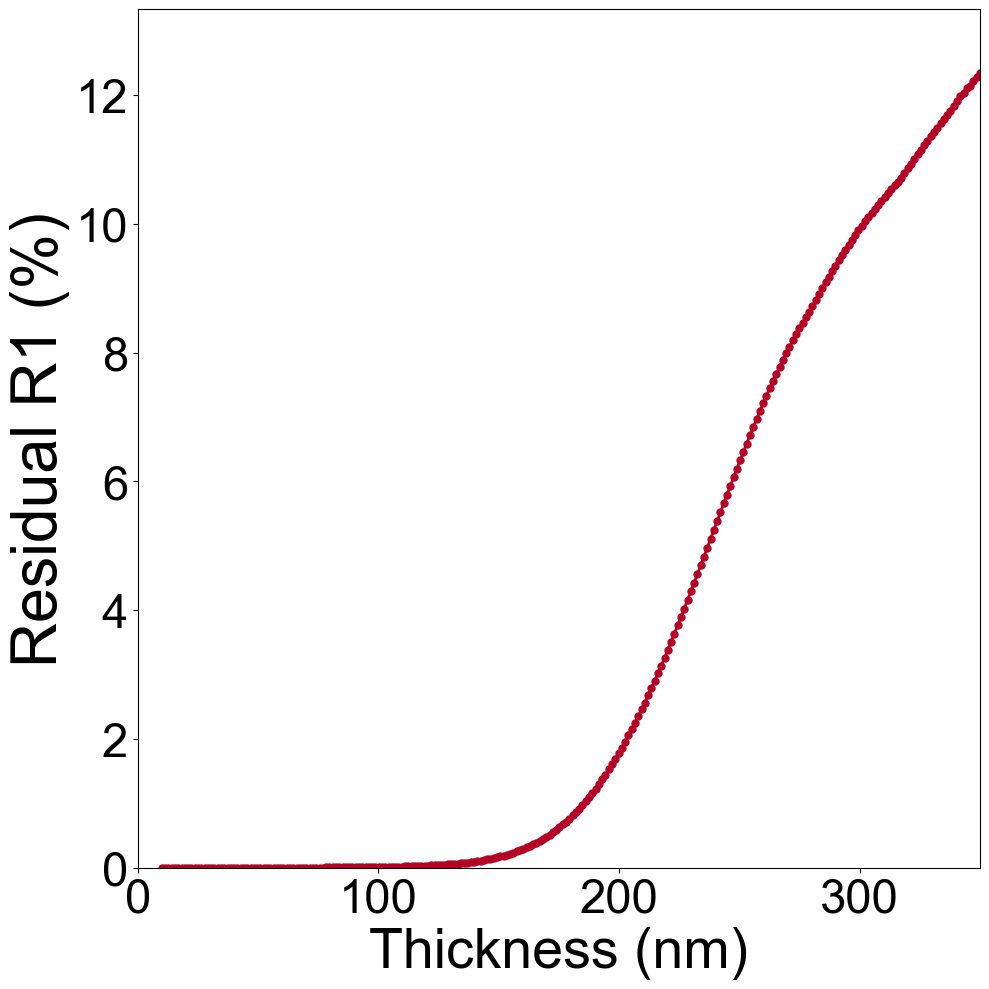

In [14]:
# ===================================================================
# R FACTOR: NUMERICAL INTEGRATION VS ANALYTICAL EXPRESSION
# Same aesthetics as full two-panel figure
# ===================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams["font.family"] = "Arial"

# -------------------------------------------------------------------
# Use variables from your full figure cell
# -------------------------------------------------------------------
orientation = "orientation_1"
results = results_by_orientation[orientation]

with_abs = results["with_abs"]
without_abs = results["without_abs"]
t_nm = np.asarray(results["t_values"], dtype=float) / 10.0
t = np.asarray(results["t_values"], dtype=float)
beams = results["beams"]

beam_hkls = [tuple(b["hkl"]) for b in beams]

analytic_beams = beams_by_orientation[orientation]
analytic_hkls = [tuple(b["hkl"]) for b in analytic_beams]

# -------------------------------------------------------------------
# Compute R per thickness
# obs  = numerical integrated absorption ratio
# calc = analytical closed-form expression
# -------------------------------------------------------------------
r_rows = []

for j, thickness_nm in enumerate(t_nm):
    obs = []
    calc = []

    for beam, num_with, num_without in zip(beams, with_abs, without_abs):
        hkl = tuple(beam["hkl"])

        if hkl not in analytic_hkls:
            continue

        num_with = np.asarray(num_with, dtype=float)
        num_without = np.asarray(num_without, dtype=float)

        if num_without[j] == 0:
            continue

        numerical_ratio = num_with[j] / num_without[j]

        if not np.isfinite(numerical_ratio) or numerical_ratio <= 0:
            continue

        analytic_beam = analytic_beams[analytic_hkls.index(hkl)]

        analytical_ratio = F_theory_A14_nextterm(
            t[j],
            analytic_beam["U_g"],
            analytic_beam["U_g_prime"]
        )

        analytical_ratio = float(np.asarray(analytical_ratio))

        if not np.isfinite(analytical_ratio) or analytical_ratio <= 0:
            continue

        obs.append(numerical_ratio)
        calc.append(analytical_ratio)

    obs = np.asarray(obs, dtype=float)
    calc = np.asarray(calc, dtype=float)

    if obs.size == 0 or np.sum(np.abs(obs)) == 0:
        continue

    denom = np.sum(calc * calc)
    scale = 0.0 if denom == 0 else np.sum(obs * calc) / denom

    R_val = np.sum(np.abs(obs - scale * calc)) / np.sum(np.abs(obs))

    r_rows.append({
        "thickness_nm": thickness_nm,
        "scale": scale,
        "R": R_val,
        "num_reflections": obs.size,
    })

r_df = pd.DataFrame(r_rows)

print(r_df.head())
print("Mean R:", r_df["R"].mean())
print("Min R:", r_df["R"].min())
print("Max R:", r_df["R"].max())

# -------------------------------------------------------------------
# Plot with same visual language as main figure
# -------------------------------------------------------------------
# -------------------------------------------------------------------
# Plot with same visual language as main figure
# -------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 10))

R_percent = 100.0 * r_df["R"].to_numpy(dtype=float)

ax.plot(
    r_df["thickness_nm"],
    R_percent,
    "o-",
    color="#b40426",
    markerfacecolor="#b40426",
    markeredgecolor="#b40426",
    markersize=5,
    linewidth=2
)


ax.set_xlabel("Thickness (nm)", fontsize=40)
ax.set_ylabel("Residual R1 (%)", fontsize=45)

ax.set_xlim(0, 350)
ax.set_ylim(0, np.nanmax(R_percent) * 1.08)

ax.tick_params(axis="both", which="major", labelsize=34)

R_mu_percent = np.nanmean(R_percent)

eq_text = fr"$\overline{{R1}} = {R_mu_percent:.1f}\%$"


plt.tight_layout()
plt.show()

# Two Beam vs Many-Beam # 

/var/folders/c4/6p85bt0j36s30ymr87bddjkr0000gn/T/ipykernel_73944/740244633.py:55: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df=pd.DataFrame(rows,columns=headers).apply(pd.to_numeric,errors="ignore")


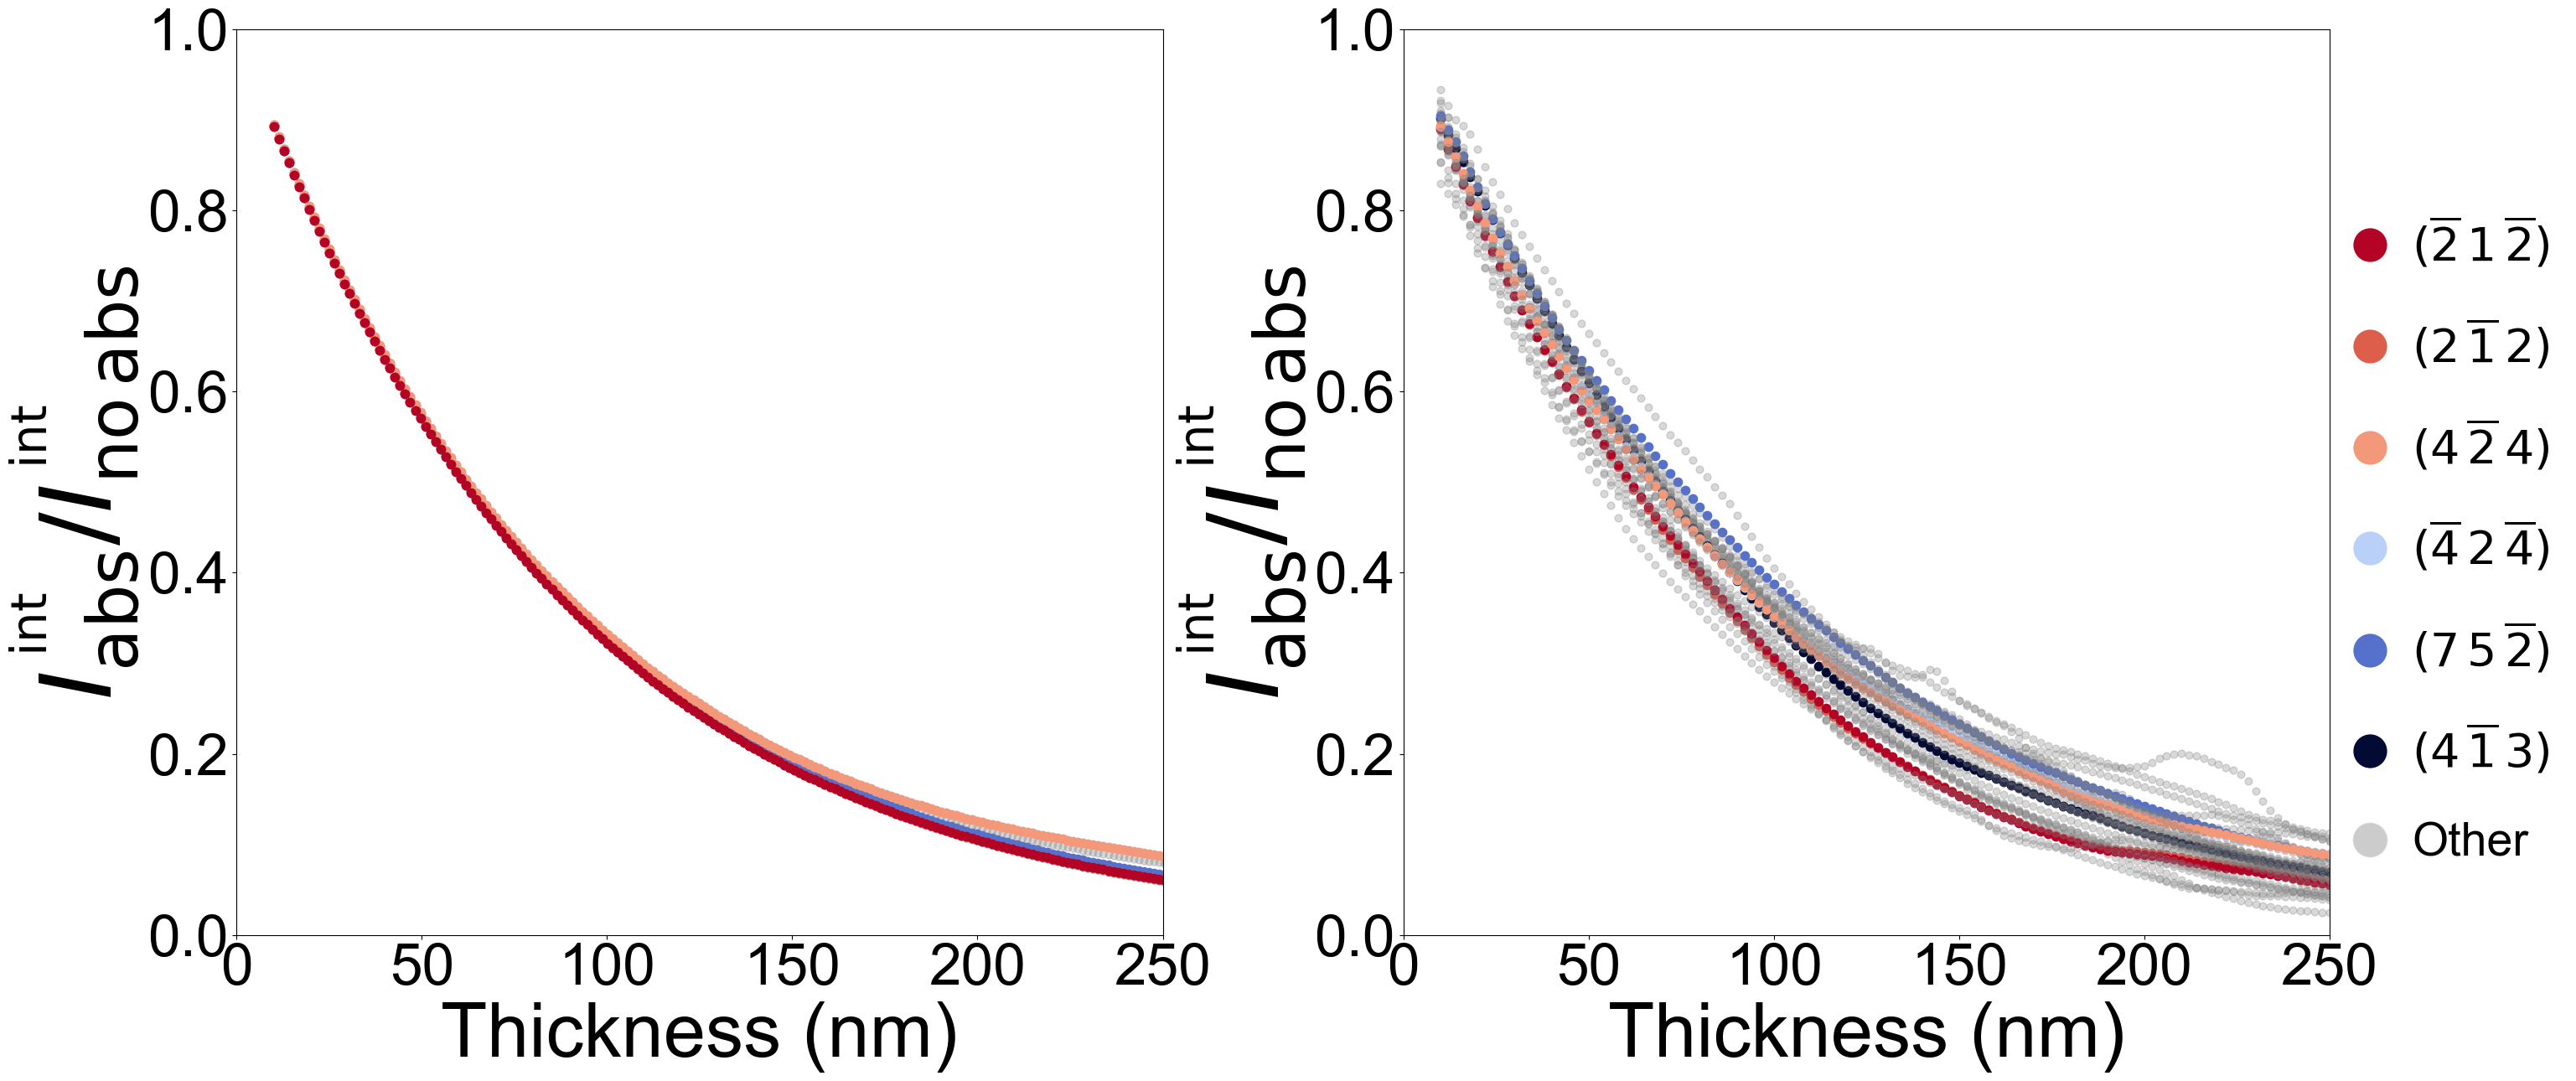

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.lines import Line2D
import re
from collections import defaultdict

plt.rcParams["font.family"] = "Arial"

def format_hkl_tex(h,k,l):
    def fmt(v): return r"\overline{%d}" % abs(v) if v < 0 else str(v)
    return f"$({fmt(h)}\,{fmt(k)}\,{fmt(l)})$"

custom_colors = {
    (-2,1,-2):"#b40426",
    (2,-1,2):"#dd5f4b",
    (4,-2,4):"#f4987a",
    (-4,2,-4):"#b9d0f9",
    (7,5,-2):"#5571cb",
    (4,-1,3):"#030a34",
}
hkls_ordered = list(custom_colors.keys())

orientation_label = "orientation_1"
results = results_by_orientation[orientation_label]
results_with_abs = results["with_abs"]
results_without_abs = results["without_abs"]
t_left = results["t_values"] / 10.0
beams_left = results["beams"]

FOLDER = Path(str(REPO_ROOT / "absorption_paper_source_data/many_beam_simulations/cspbbr/pendelloscung"))
ROTATION = 1
ABS_LABEL = "param"
NONABS_LABEL = "no_abs"
CLIP_EPS = 1e-9
THICKNESS_MIN = 10.0
CIF_EXP = str(REPO_ROOT / "diffBloch_version_0.0.1/data/cspbbr3/CsPbBr_P67-crot-050_dyn.cif_pets")

def parse_hkl(s): return tuple(int(x) for x in s.strip().split())

def get_hkls_above_3sigma(cif_file):
    with open(cif_file) as f: lines=f.readlines()
    start=None
    for i,l in enumerate(lines):
        if l.strip().startswith("loop_") and "_refln_index_h" in "".join(lines[i+1:i+12]):
            start=i; break
    headers=[]; j=start+1
    while lines[j].strip().startswith("_refln"):
        headers.append(lines[j].strip()); j+=1
    rows=[]
    for l in lines[j:]:
        if re.match(r"^\s*[-0-9]",l): rows.append(l.split())
        else: break
    df=pd.DataFrame(rows,columns=headers).apply(pd.to_numeric,errors="ignore")
    mask=df["_refln_intensity_meas"]>3*df["_refln_intensity_sigma"]
    out=set()
    for a,b,c,m in zip(df["_refln_index_h"],df["_refln_index_k"],df["_refln_index_l"],mask):
        if m: out.add((int(a),int(b),int(c)))
    return out

HKL_FILTER=get_hkls_above_3sigma(CIF_EXP)

abs_re=re.compile(rf"{ABS_LABEL}_rotation_{ROTATION}_thickness_([0-9.]+)_intensities\.csv$")
nonabs_re=re.compile(rf"{NONABS_LABEL}_rotation_{ROTATION}_thickness_([0-9.]+)_intensities\.csv$")

abs_map={}; nonabs_map={}
for p in FOLDER.glob(f"{ABS_LABEL}_rotation_{ROTATION}_thickness_*_intensities.csv"):
    m=abs_re.search(p.name)
    if m: abs_map[float(m.group(1))]=p
for p in FOLDER.glob(f"{NONABS_LABEL}_rotation_{ROTATION}_thickness_*_intensities.csv"):
    m=nonabs_re.search(p.name)
    if m: nonabs_map[float(m.group(1))]=p

common_thicks=sorted(set(abs_map)&set(nonabs_map))
t_right=[t/10.0 for t in common_thicks]

per_hkl=defaultdict(lambda:{"t":[], "ratio":[]})

for tA,t_nm in zip(common_thicks,t_right):
    if t_nm<THICKNESS_MIN: continue
    dfA=pd.read_csv(abs_map[tA],dtype={"HKL":str})
    dfN=pd.read_csv(nonabs_map[tA],dtype={"HKL":str})
    dA={s.strip():float(I) for s,I in zip(dfA["HKL"],dfA["Intensity"])}
    dN={s.strip():float(I) for s,I in zip(dfN["HKL"],dfN["Intensity"])}
    for hstr in set(dA)&set(dN):
        hkl=parse_hkl(hstr)
        if hkl not in HKL_FILTER: continue
        Ia=dA[hstr]; In=dN[hstr]
        if In<=0: continue
        R=np.clip(Ia/In,CLIP_EPS,1.0)
        per_hkl[hstr]["t"].append(t_nm)
        per_hkl[hstr]["ratio"].append(R)

fig,axes=plt.subplots(1,2,figsize=(28,13))
axL,axR=axes

# LEFT PANEL
for beam,wA,wN in zip(beams_left,results_with_abs,results_without_abs):
    hkl=tuple(beam["hkl"])
    ratio=np.divide(wA,wN,out=np.full_like(wA,np.nan),where=(np.array(wN)!=0))
    valid=~np.isnan(ratio)
    if not np.any(valid): continue
    axL.scatter(t_left[valid],ratio[valid],color="grey",s=40,alpha=0.3)

for hkl in reversed(hkls_ordered):
    idx=[tuple(b["hkl"]) for b in beams_left].index(hkl)
    wA=results_with_abs[idx]; wN=results_without_abs[idx]
    ratio=np.divide(wA,wN,out=np.full_like(wA,np.nan),where=(np.array(wN)!=0))
    valid=~np.isnan(ratio)
    axL.scatter(t_left[valid],ratio[valid],color=custom_colors[hkl],s=55)

axL.set_xlabel("Thickness (nm)",fontsize=65)
axL.set_ylabel(r"$I_\mathrm{abs}^{\;\!{}^{\mathrm{int}}} / I_\mathrm{no\,abs}^{\;\!{}^{\mathrm{int}}}$",fontsize=85)
axL.set_xlim(0,250); axL.set_ylim(0,1)
axL.tick_params(labelsize=50)

# RIGHT PANEL
for hstr,rec in per_hkl.items():
    hkl=parse_hkl(hstr)
    t=np.array(rec["t"]); r=np.array(rec["ratio"])
    if hkl in custom_colors:
        axR.scatter(t,r,color=custom_colors[hkl],s=55)
    else:
        axR.scatter(t,r,color="grey",alpha=0.3,s=40)

axR.set_xlabel("Thickness (nm)",fontsize=65)
axR.set_ylabel(r"$I_\mathrm{abs}^{\;\!{}^{\mathrm{int}}} / I_\mathrm{no\,abs}^{\;\!{}^{\mathrm{int}}}$",fontsize=85)
axR.set_xlim(0,250); axR.set_ylim(0,1)
axR.tick_params(labelsize=50)

# LEGEND OUTSIDE RIGHT SIDE
legend_handles=[]
legend_labels=[]
for hkl in hkls_ordered:
    legend_handles.append(Line2D([0],[0],marker='o',color='w',
                                 markerfacecolor=custom_colors[hkl],
                                 markersize=24))
    legend_labels.append(format_hkl_tex(*hkl))

legend_handles.append(Line2D([0],[0],marker='o',color='w',
                             markerfacecolor='grey',alpha=0.4,markersize=18))
legend_labels.append("Other")
# ------------------------------------------------------------
# IMPROVED LEGEND: tighter, closer, wider vertical spacing
# ------------------------------------------------------------
legend_handles = []
legend_labels = []

for hkl in hkls_ordered:
    legend_handles.append(
        Line2D([0],[0],
               marker='o',
               color='w',
               markerfacecolor=custom_colors[hkl],
               markersize=30)
    )
    legend_labels.append(format_hkl_tex(*hkl))

legend_handles.append(
    Line2D([0],[0],
           marker='o',
           color='w',
           markerfacecolor='grey',
           alpha=0.4,
           markersize=30)
)
legend_labels.append("Other")

fig.legend(
    legend_handles,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(0.99, 0.5),   # closer to figure
    borderaxespad=0.2,            # small padding
    labelspacing=1.0,             # vertical spacing between entries
    handlelength=1.0,
    handletextpad=0.4,
    fontsize=40,
    frameon=False
)

plt.tight_layout()
plt.show()


   thickness_nm       scale         R  num_reflections
0          10.0  981.291854  0.032925               29
1          12.0  992.613281  0.037066               29
2          14.0  991.868656  0.048389               29
3          16.0  990.325754  0.062576               29
4          18.0  988.389863  0.071039               29


/var/folders/c4/6p85bt0j36s30ymr87bddjkr0000gn/T/ipykernel_73944/3763469388.py:88: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/benjamincolmey/anaconda3/envs/abtem/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


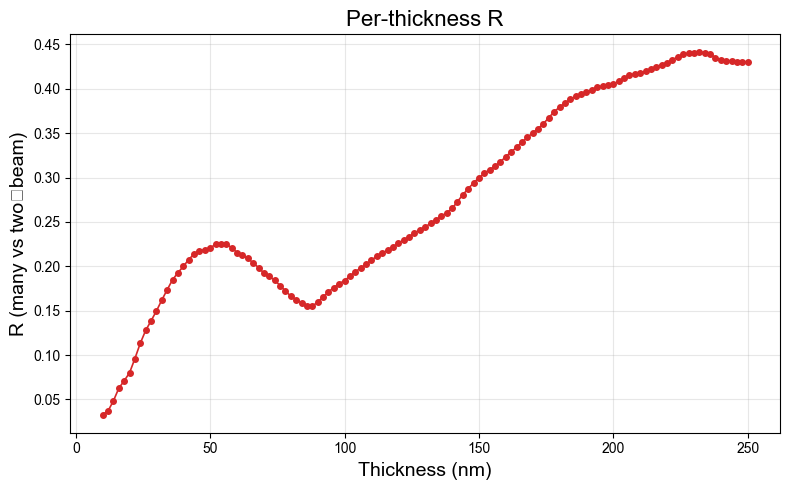

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob

# --- load many-beam no-abs files and derive thickness (nm) from filename ---
folder = Path(str(REPO_ROOT / "absorption_paper_source_data/many_beam_simulations/cspbbr/pendelloscung"))
files = [p for p in glob.glob(str(folder / "*.csv"))
         if "_rotation_1_" in p and "rocking" not in p.lower()
         and "no_abs_rotation_1_" in p]

frames = []
for p in files:
    thickness_nm = float(Path(p).name.split("_thickness_")[1].split("_")[0]) / 10.0
    tmp = pd.read_csv(p)
    tmp["thickness_nm"] = thickness_nm
    frames.append(tmp)
df_mb = pd.concat(frames, ignore_index=True)

def parse_hkl(s: str):
    parts = s.strip().replace(",", " ").split()
    return tuple(int(p) for p in parts) if len(parts) == 3 else None

df_mb["HKL_tuple"] = df_mb["HKL"].apply(parse_hkl)
df_mb = df_mb[df_mb["HKL_tuple"].notna()]

# many-beam map: thickness -> {hkl: intensity}
many_by_t = {}
for t_nm, grp in df_mb.groupby("thickness_nm"):
    many_by_t[t_nm] = {hkl: float(I) for hkl, I in zip(grp["HKL_tuple"], grp["Intensity"])}

# --- load two-beam no-abs results (orientation_1) ---
def load_results_from_csv(csv_path: str):
    df = pd.read_csv(csv_path)
    res = {}
    for orientation, g in df.groupby("orientation"):
        t_vals = np.array(sorted(g["thickness_A"].unique()), dtype=float)
        hkls = g[["h", "k", "l"]].drop_duplicates().itertuples(index=False, name=None)
        beams, without = [], []
        for hkl in hkls:
            sub = g[(g["h"] == hkl[0]) & (g["k"] == hkl[1]) & (g["l"] == hkl[2])].sort_values("thickness_A")
            sub = sub.groupby("thickness_A", as_index=True)["I_without_abs"].mean()
            curve = sub.reindex(t_vals).to_numpy(dtype=float)
            beams.append({"hkl": hkl})
            without.append(curve)
        res[orientation] = {"beams": beams, "t_values": t_vals, "without_abs": np.vstack(without)}
    return res

tb = load_results_from_csv(str(REPO_ROOT / "absorption_paper_source_data/two_beam/two_beam_intensities_orientation1_filtered_Lcorrected.csv"))["orientation_1"]
t_two_nm = tb["t_values"] / 10.0  # Å -> nm
two_curves = {tuple(b["hkl"]): np.array(tb["without_abs"][i]) for i, b in enumerate(tb["beams"])}

# --- compute R per thickness ---
r_rows = []
for t_nm, mb_vals in sorted(many_by_t.items()):
    obs, calc = [], []
    for hkl, mb_int in mb_vals.items():
        curve = two_curves.get(hkl)
        if curve is None:
            continue
        valid_curve = np.isfinite(curve)
        if valid_curve.sum() < 2:
            continue
        calc_val = float(np.interp(t_nm, t_two_nm[valid_curve], curve[valid_curve], left=np.nan, right=np.nan))
        if np.isnan(calc_val):
            continue
        obs.append(mb_int)
        calc.append(calc_val)
    obs = np.array(obs, float)
    calc = np.array(calc, float)
    if obs.size == 0 or np.sum(np.abs(obs)) == 0:
        continue
    denom = np.sum(calc * calc)
    scale = 0.0 if denom == 0 else np.sum(obs * calc) / denom
    R_val = np.sum(np.abs(obs - scale * calc)) / np.sum(np.abs(obs))
    r_rows.append((t_nm, scale, R_val, obs.size))

r_df = pd.DataFrame(r_rows, columns=["thickness_nm", "scale", "R", "num_reflections"])
print(r_df.head())
# after building r_df
plt.figure(figsize=(8, 5))
plt.plot(r_df["thickness_nm"], r_df["R"], "o-", color="tab:red", markersize=4, linewidth=1.2)
plt.xlabel("Thickness (nm)", fontsize=14)
plt.ylabel("R (many vs two‑beam)", fontsize=14)
plt.title("Per-thickness R", fontsize=16)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



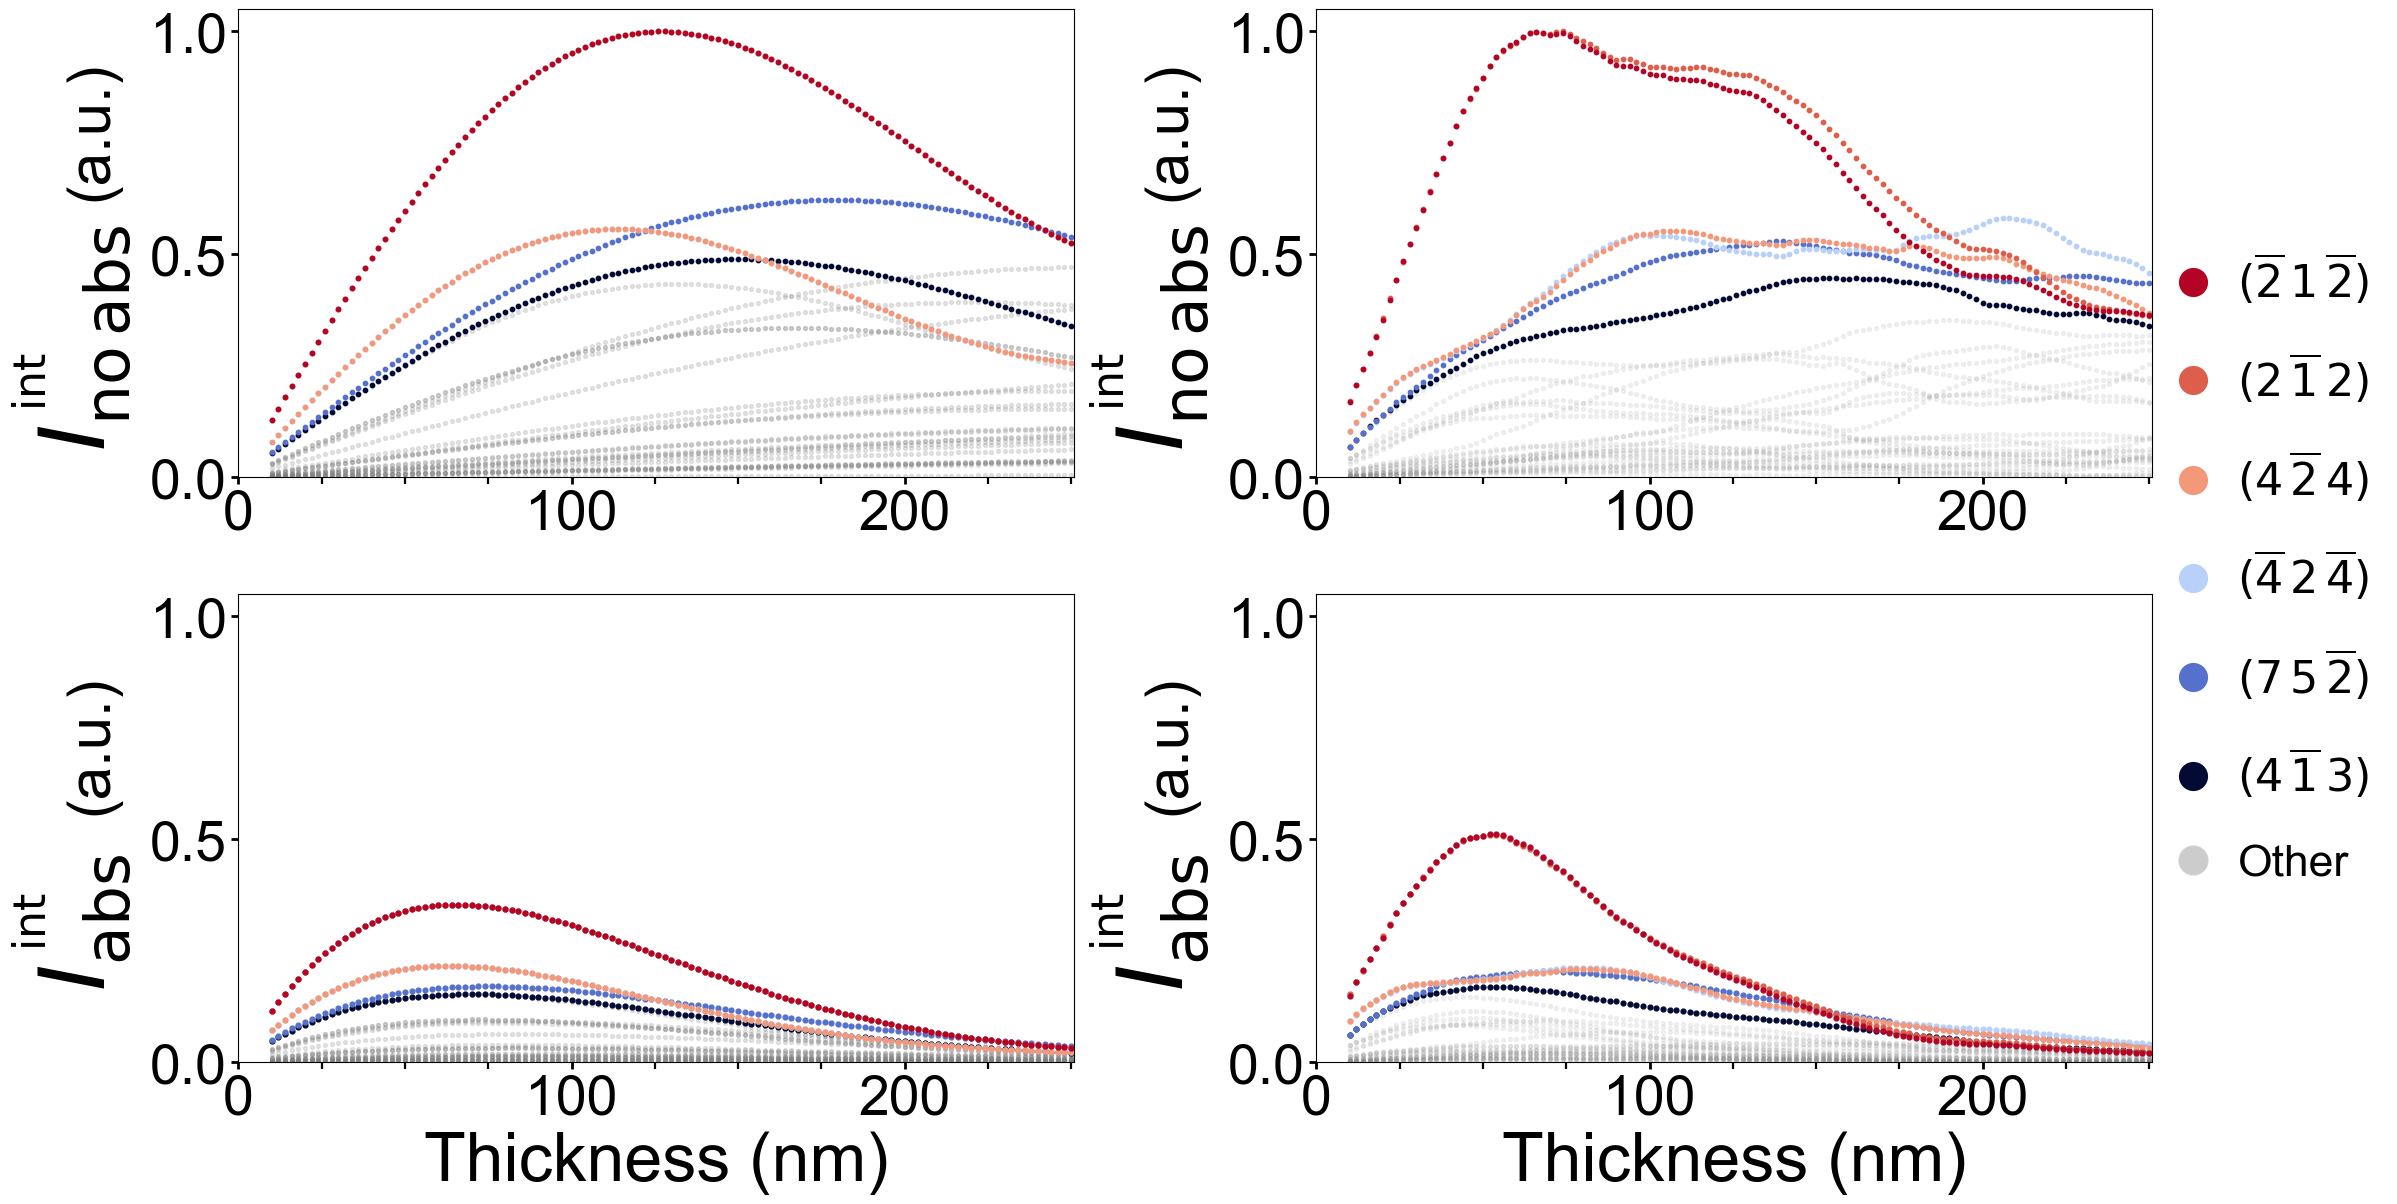

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.lines import Line2D
from matplotlib.ticker import ScalarFormatter

plt.rcParams["font.family"] = "Arial"

def format_hkl_tex(h, k, l):
    def fmt(v): return r"\overline{%d}" % abs(v) if v < 0 else str(v)
    return f"$({fmt(h)}\,{fmt(k)}\,{fmt(l)})$"

# --------------------------------------------------------
# LEFT (2-beam) DATA
# --------------------------------------------------------
def load_two_beam_results_from_csv(csv_path):
    df = pd.read_csv(csv_path)
    out = {}
    for orientation, g in df.groupby("orientation"):
        t_vals = np.array(sorted(g["thickness_A"].unique()), dtype=float)
        hkls = list(g[["h", "k", "l"]].drop_duplicates().itertuples(index=False, name=None))
        beams, with_abs_list, without_abs_list = [], [], []
        for hkl in hkls:
            sub = g[(g["h"] == hkl[0]) & (g["k"] == hkl[1]) & (g["l"] == hkl[2])].sort_values("thickness_A")
            sub = sub.groupby("thickness_A", as_index=True)[["I_with_abs", "I_without_abs"]].mean()
            beams.append({"hkl": hkl})
            with_abs_list.append(sub["I_with_abs"].reindex(t_vals).to_numpy(dtype=float))
            without_abs_list.append(sub["I_without_abs"].reindex(t_vals).to_numpy(dtype=float))
        out[orientation] = {
            "beams": beams,
            "t_values": t_vals,
            "with_abs": np.vstack(with_abs_list),
            "without_abs": np.vstack(without_abs_list),
        }
    return out

two_beam_lcorrected_csv = str(REPO_ROOT / "absorption_paper_source_data/two_beam/two_beam_intensities_orientation1_filtered_Lcorrected.csv")
results_by_orientation_left = load_two_beam_results_from_csv(two_beam_lcorrected_csv)

selected_orientation = "orientation_1"
results_with_abs_left  = results_by_orientation_left[selected_orientation]["with_abs"]
results_without_abs_left = results_by_orientation_left[selected_orientation]["without_abs"]
t_left = results_by_orientation_left[selected_orientation]["t_values"] / 10.0
beams_left = results_by_orientation_left[selected_orientation]["beams"]

hkls_ordered = [
    (-2,1,-2),(2,-1,2),
    (4,-2,4),(-4,2,-4),
    (7,5,-2),(4,-1,3)
]

custom_colors = {
    (-2,1,-2):"#b40426",
    (2,-1,2):"#dd5f4b",
    (4,-2,4):"#f4987a",
    (-4,2,-4):"#b9d0f9",
    (7,5,-2):"#5571cb",
    (4,-1,3):"#030a34"
}

all_vals_left = np.concatenate([
    np.array(results_with_abs_left).flatten(),
    np.array(results_without_abs_left).flatten()
])
ymax_left = np.nanmax(all_vals_left)

# --------------------------------------------------------
# RIGHT (many-beam) DATA
# --------------------------------------------------------
base_dir = Path(str(REPO_ROOT / "absorption_paper_source_data/many_beam_simulations/cspbbr/pendelloscung"))

no_abs_files = sorted(base_dir.glob("no_abs_rotation_1_thickness_*_intensities.csv"))
abs_files    = sorted(base_dir.glob("param_rotation_1_thickness_*_intensities.csv"))

def parse_thickness(f):
    parts = f.stem.split("_")
    return float(parts[-2])

t_right_A = np.array([parse_thickness(f) for f in no_abs_files])
t_right_nm = t_right_A / 10.0

def load_intensities(files):
    out = []
    for f in files:
        df = pd.read_csv(f)
        df["HKL"] = df["HKL"].apply(lambda s: tuple(map(int, s.split())))
        out.append(dict(zip(df["HKL"], df["Intensity"])))
    return out, list(df["HKL"].unique())

no_abs_data, hkls_all = load_intensities(no_abs_files)
abs_data, _           = load_intensities(abs_files)

# allowed HKLs
allowed = pd.read_csv(
    str(REPO_ROOT / "absorption_paper_source_data/two_beam/allowed_hkls.csv")
)
allowed_hkls = {tuple(map(int,s.split())) for s in allowed["HKL"].tolist()}

vals_no  = [d.get(h,0) for d in no_abs_data for h in hkls_all]
vals_abs = [d.get(h,0) for d in abs_data for h in hkls_all]
ymax_right = np.nanmax(vals_no + vals_abs)

# --------------------------------------------------------
# CREATE NON-DISTORTED CANVAS
# --------------------------------------------------------
fig = plt.figure(figsize=(22,13))   # EXACT same scaling as your decay plots

# identical aspect by fixing subplot positions manually:
axL_top = fig.add_axes([0.06, 0.57, 0.38, 0.36])
axL_bot = fig.add_axes([0.06, 0.12, 0.38, 0.36])
axR_top = fig.add_axes([0.55, 0.57, 0.38, 0.36])
axR_bot = fig.add_axes([0.55, 0.12, 0.38, 0.36])

# --------------------------------------------------------
# LEFT TOP — NO ABSORPTION (unchanged)
# --------------------------------------------------------
maskL = t_left >= 0

# grey
for i, b in enumerate(beams_left):
    hkl = tuple(b["hkl"])
    if hkl not in hkls_ordered:
        y = np.array(results_without_abs_left[i]) / ymax_left
        axL_top.scatter(t_left[maskL], y[maskL], color="grey", s=8, alpha=0.2)

# coloured
for hkl in reversed(hkls_ordered):
    idx = [tuple(b["hkl"]) for b in beams_left].index(hkl)
    y = np.array(results_without_abs_left[idx]) / ymax_left
    axL_top.scatter(t_left[maskL], y[maskL], color=custom_colors[hkl], s=10)

axL_top.set_ylim(0,1.05)
axL_top.set_xlim(0,251)
axL_top.set_yticks([0,0.5,1.0])
axL_top.set_ylabel(r"$I_\mathrm{no\,abs}^{\;\!{}^{\mathrm{int}}}$", fontsize=65)
axL_top.tick_params(labelsize=40)

# --------------------------------------------------------
# LEFT BOTTOM — WITH ABSORPTION (unchanged)
# --------------------------------------------------------
for i, b in enumerate(beams_left):
    hkl = tuple(b["hkl"])
    if hkl not in hkls_ordered:
        y = np.array(results_with_abs_left[i]) / ymax_left
        axL_bot.scatter(t_left[maskL], y[maskL], color="grey", s=8, alpha=0.2)

for hkl in reversed(hkls_ordered):
    idx = [tuple(b["hkl"]) for b in beams_left].index(hkl)
    y = np.array(results_with_abs_left[idx]) / ymax_left
    axL_bot.scatter(t_left[maskL], y[maskL], color=custom_colors[hkl], s=12)

axL_bot.set_ylim(0,1.05)
axL_bot.set_xlim(0,251)
axL_bot.set_yticks([0,0.5,1.0])
axL_bot.set_ylabel(r"$I_\mathrm{abs}^{\;\!{}^{\mathrm{int}}}$", fontsize=65)
axL_bot.set_xlabel("Thickness (nm)", fontsize=49)
axL_bot.tick_params(labelsize=40)

# --------------------------------------------------------
# RIGHT TOP — NO ABS (unchanged)
# --------------------------------------------------------
maskR = t_right_nm >= 0

for h in hkls_all:
    if h not in allowed_hkls: continue
    if h not in hkls_ordered:
        y = np.array([d.get(h,np.nan) for d in no_abs_data]) / ymax_right
        axR_top.scatter(t_right_nm[maskR], y[maskR], color="grey", s=8, alpha=0.1)

for hkl in reversed(hkls_ordered):
    y = np.array([d.get(hkl,np.nan) for d in no_abs_data]) / ymax_right
    axR_top.scatter(t_right_nm[maskR], y[maskR], color=custom_colors[hkl], s=10)

axR_top.set_ylim(0,1.05)
axR_top.set_xlim(0,251)
axR_top.set_yticks([0,0.5,1.0])
axR_top.set_ylabel(r"$I_\mathrm{no\,abs}^{\;\!{}^{\mathrm{int}}}$", fontsize=65)
axR_top.tick_params(labelsize=40)

# --------------------------------------------------------
# RIGHT BOTTOM — ABS (unchanged)
# --------------------------------------------------------
for h in hkls_all:
    if h not in allowed_hkls: continue
    if h not in hkls_ordered:
        y = np.array([d.get(h,np.nan) for d in abs_data]) / ymax_right
        axR_bot.scatter(t_right_nm[maskR], y[maskR], color="grey", s=8, alpha=0.1)

for hkl in reversed(hkls_ordered):
    y = np.array([d.get(hkl,np.nan) for d in abs_data]) / ymax_right
    axR_bot.scatter(t_right_nm[maskR], y[maskR], color=custom_colors[hkl], s=12)

axR_bot.set_ylim(0,1.05)
axR_bot.set_xlim(0,251)
axL_top.set_xticks([0,100,200]); axL_top.set_xticks(np.arange(0,251,25), minor=True)

axR_bot.set_yticks([0,0.5,1.0])
axR_bot.set_ylabel(r"$I_\mathrm{abs}^{\;\!{}^{\mathrm{int}}}$", fontsize=65)
axR_bot.set_xlabel("Thickness (nm)", fontsize=49)
axR_bot.tick_params(labelsize=40)
for ax in [axL_top, axL_bot, axR_top, axR_bot]:
    ax.set_xticks([0,100,200])
    ax.set_xticks(np.arange(0,251,25), minor=True)

# --------------------------------------------------------
# LEGEND — identical to decay plots, placed OUTSIDE right
# --------------------------------------------------------
legend_handles = [
    Line2D([0],[0],marker='o',color='w',
           markerfacecolor=custom_colors[h],markersize=22)
    for h in hkls_ordered
]
legend_labels = [format_hkl_tex(*h) for h in hkls_ordered]

legend_handles.append(Line2D([0],[0],marker='o',color='w',
                             markerfacecolor='grey',alpha=0.4,markersize=22))
legend_labels.append("Other")
for ax in [axL_top, axL_bot, axR_top, axR_bot]:
    ax.tick_params(axis="both", which="major", length=5, width=2)
    ax.tick_params(axis="both", which="minor", length=5, width=1.6)

# ---------- COMMON X ALIGNMENT ----------
label_x = -0.125
au_x    = -0.175
# ---------- LEFT TOP ----------
axL_top.set_ylabel(
    r"$I_\mathrm{no\,abs}^{\;\!{}^{\mathrm{int}}}$",
    fontsize=65,
    labelpad=25
)
axL_top.yaxis.set_label_coords(label_x, 0.30)

axL_top.text(
    au_x, 0.74,
    "(a.u.)",
    transform=axL_top.transAxes,
    rotation=90,
    fontsize=43,
    va="center",
    ha="center"
)

# ---------- LEFT BOTTOM ----------
axL_bot.set_ylabel(
    r"$I_\mathrm{abs}^{\;\!{}^{\mathrm{int}}}$",
    fontsize=65,
    labelpad=25
)
axL_bot.yaxis.set_label_coords(label_x, 0.30)

axL_bot.text(
    au_x, 0.68,
    "(a.u.)",
    transform=axL_bot.transAxes,
    rotation=90,
    fontsize=43,
    va="center",
    ha="center"
)

# ---------- RIGHT TOP ----------
axR_top.set_ylabel(
    r"$I_\mathrm{no\,abs}^{\;\!{}^{\mathrm{int}}}$",
    fontsize=65,
    labelpad=25
)
axR_top.yaxis.set_label_coords(label_x, 0.30)

axR_top.text(
    au_x, 0.74,
    "(a.u.)",
    transform=axR_top.transAxes,
    rotation=90,
    fontsize=43,
    va="center",
    ha="center"
)

# ---------- RIGHT BOTTOM ----------
axR_bot.set_ylabel(
    r"$I_\mathrm{abs}^{\;\!{}^{\mathrm{int}}}$",
    fontsize=65,
    labelpad=25
)
axR_bot.yaxis.set_label_coords(label_x, 0.30)

axR_bot.text(
    au_x, 0.68,
    "(a.u.)",
    transform=axR_bot.transAxes,
    rotation=90,
    fontsize=43,
    va="center",
    ha="center"
)
fig.legend(
    legend_handles,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(0.93,0.5),
    borderaxespad=0.01,
    labelspacing=1.0,
    handlelength=1.0,
    handletextpad=0.5,
    fontsize=32,
    frameon=False
)

plt.show()


/var/folders/c4/6p85bt0j36s30ymr87bddjkr0000gn/T/ipykernel_73944/1707313747.py:55: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df=pd.DataFrame(rows,columns=headers).apply(pd.to_numeric,errors="ignore")


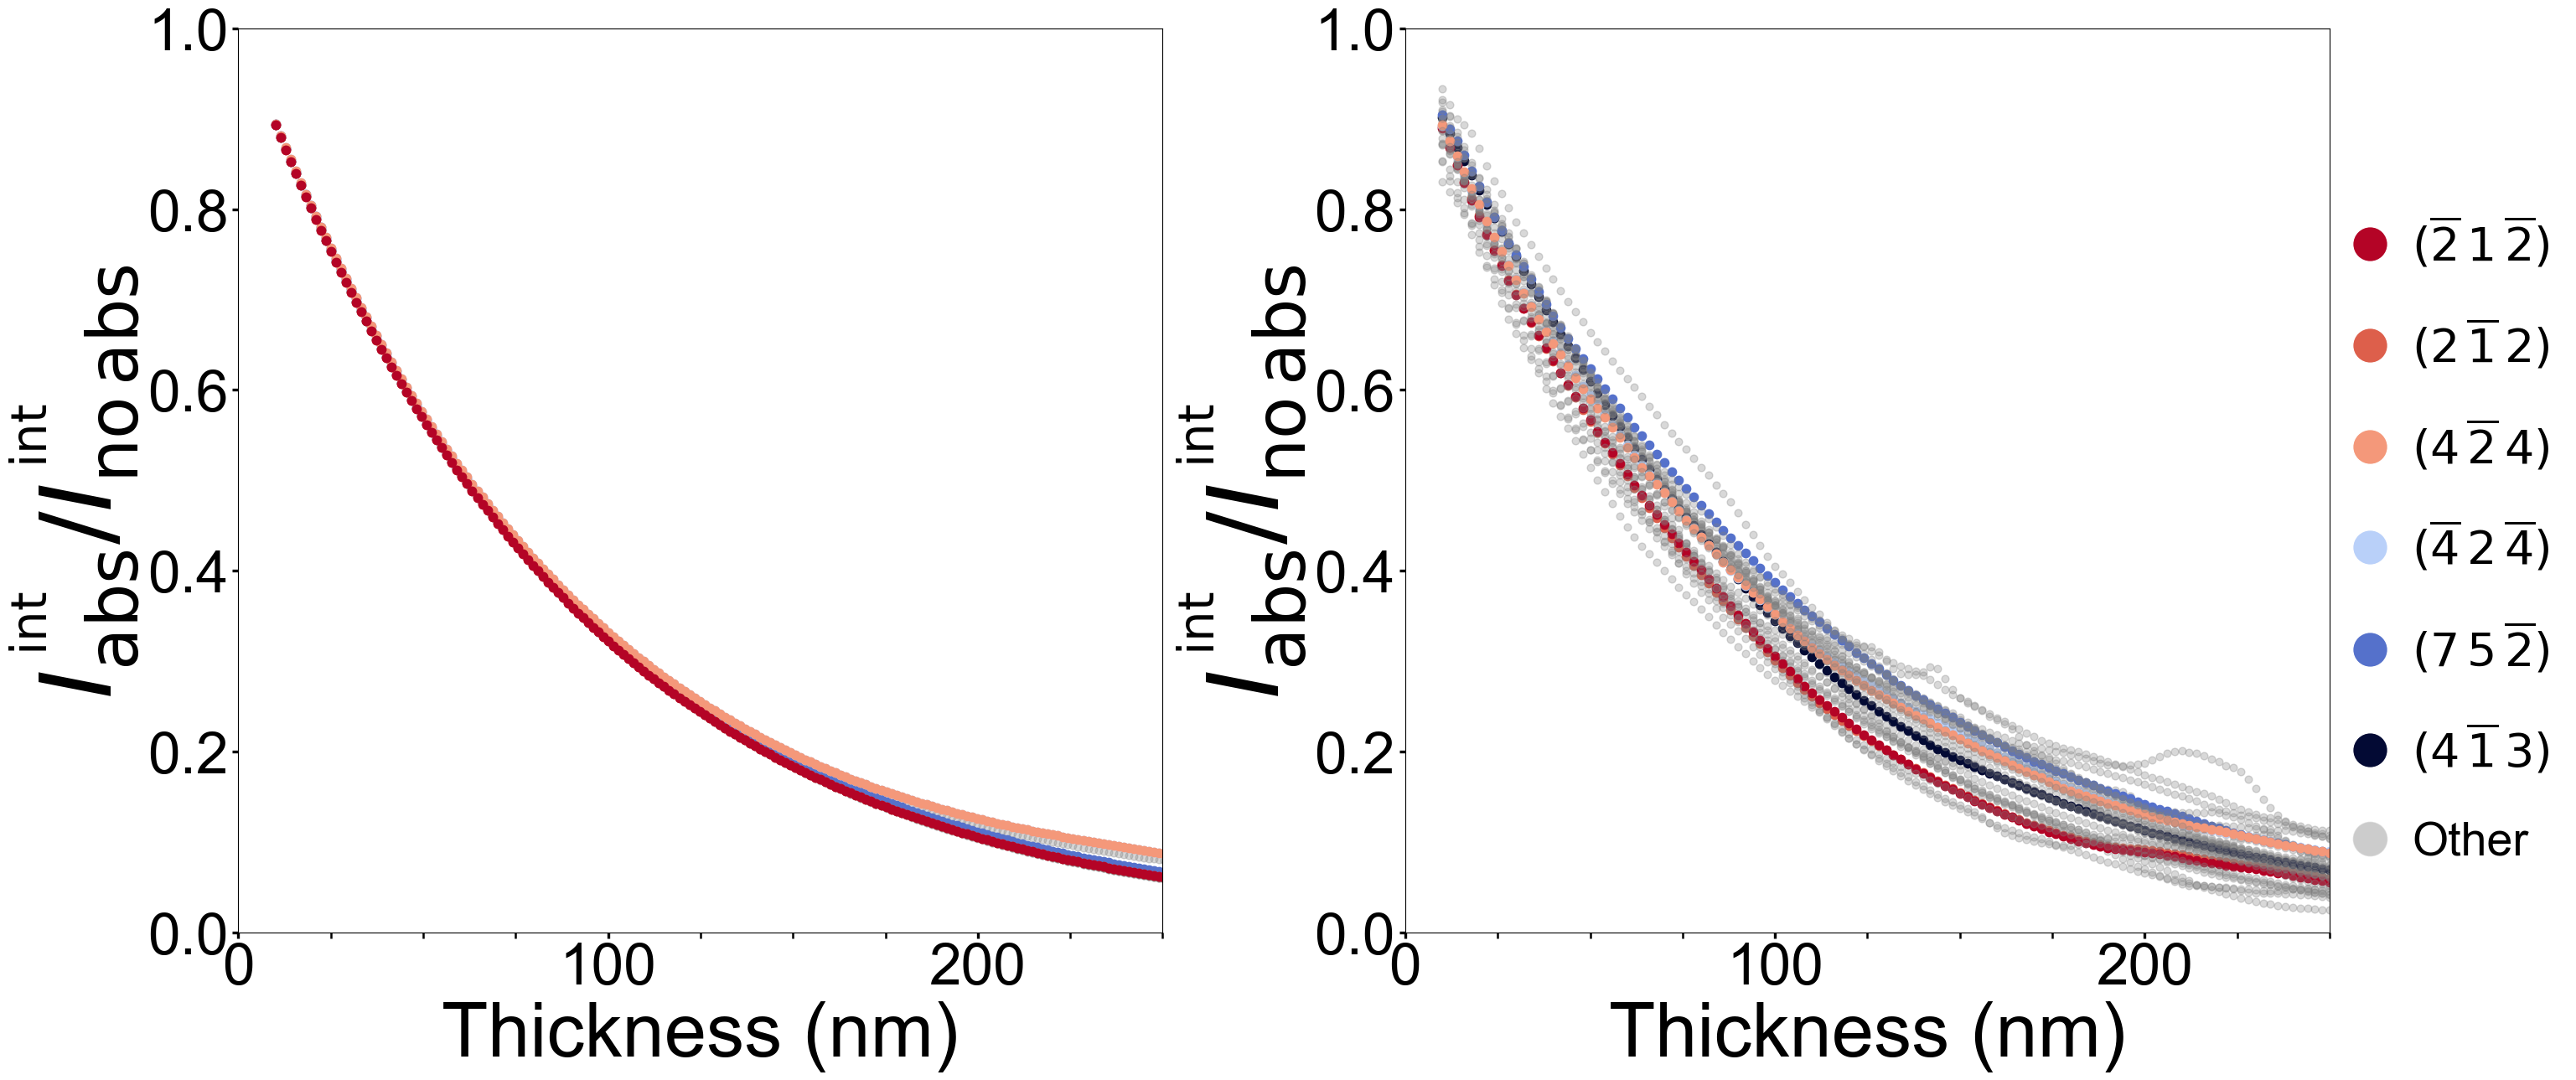

In [18]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.lines import Line2D
import re
from collections import defaultdict

plt.rcParams["font.family"] = "Arial"

def format_hkl_tex(h,k,l):
    def fmt(v): return r"\overline{%d}" % abs(v) if v < 0 else str(v)
    return f"$({fmt(h)}\,{fmt(k)}\,{fmt(l)})$"

custom_colors = {
    (-2,1,-2):"#b40426",
    (2,-1,2):"#dd5f4b",
    (4,-2,4):"#f4987a",
    (-4,2,-4):"#b9d0f9",
    (7,5,-2):"#5571cb",
    (4,-1,3):"#030a34",
}
hkls_ordered = list(custom_colors.keys())

orientation_label = "orientation_1"
results = results_by_orientation[orientation_label]
results_with_abs = results["with_abs"]
results_without_abs = results["without_abs"]
t_left = results["t_values"] / 10.0
beams_left = results["beams"]

FOLDER = Path(str(REPO_ROOT / "absorption_paper_source_data/many_beam_simulations/cspbbr/pendelloscung"))
ROTATION = 1
ABS_LABEL = "param"
NONABS_LABEL = "no_abs"
CLIP_EPS = 1e-9
THICKNESS_MIN = 10.0
CIF_EXP = str(REPO_ROOT / "diffBloch_version_0.0.1/data/cspbbr3/CsPbBr_P67-crot-050_dyn.cif_pets")

def parse_hkl(s): return tuple(int(x) for x in s.strip().split())

def get_hkls_above_3sigma(cif_file):
    with open(cif_file) as f: lines=f.readlines()
    start=None
    for i,l in enumerate(lines):
        if l.strip().startswith("loop_") and "_refln_index_h" in "".join(lines[i+1:i+12]):
            start=i; break
    headers=[]; j=start+1
    while lines[j].strip().startswith("_refln"):
        headers.append(lines[j].strip()); j+=1
    rows=[]
    for l in lines[j:]:
        if re.match(r"^\s*[-0-9]",l): rows.append(l.split())
        else: break
    df=pd.DataFrame(rows,columns=headers).apply(pd.to_numeric,errors="ignore")
    mask=df["_refln_intensity_meas"]>3*df["_refln_intensity_sigma"]
    out=set()
    for a,b,c,m in zip(df["_refln_index_h"],df["_refln_index_k"],df["_refln_index_l"],mask):
        if m: out.add((int(a),int(b),int(c)))
    return out

HKL_FILTER=get_hkls_above_3sigma(CIF_EXP)

abs_re=re.compile(rf"{ABS_LABEL}_rotation_{ROTATION}_thickness_([0-9.]+)_intensities\.csv$")
nonabs_re=re.compile(rf"{NONABS_LABEL}_rotation_{ROTATION}_thickness_([0-9.]+)_intensities\.csv$")

abs_map={}; nonabs_map={}
for p in FOLDER.glob(f"{ABS_LABEL}_rotation_{ROTATION}_thickness_*_intensities.csv"):
    m=abs_re.search(p.name)
    if m: abs_map[float(m.group(1))]=p
for p in FOLDER.glob(f"{NONABS_LABEL}_rotation_{ROTATION}_thickness_*_intensities.csv"):
    m=nonabs_re.search(p.name)
    if m: nonabs_map[float(m.group(1))]=p

common_thicks=sorted(set(abs_map)&set(nonabs_map))
t_right=[t/10.0 for t in common_thicks]

per_hkl=defaultdict(lambda:{"t":[], "ratio":[]})

for tA,t_nm in zip(common_thicks,t_right):
    if t_nm<THICKNESS_MIN: continue
    dfA=pd.read_csv(abs_map[tA],dtype={"HKL":str})
    dfN=pd.read_csv(nonabs_map[tA],dtype={"HKL":str})
    dA={s.strip():float(I) for s,I in zip(dfA["HKL"],dfA["Intensity"])}
    dN={s.strip():float(I) for s,I in zip(dfN["HKL"],dfN["Intensity"])}
    for hstr in set(dA)&set(dN):
        hkl=parse_hkl(hstr)
        if hkl not in HKL_FILTER: continue
        Ia=dA[hstr]; In=dN[hstr]
        if In<=0: continue
        R=np.clip(Ia/In,CLIP_EPS,1.0)
        per_hkl[hstr]["t"].append(t_nm)
        per_hkl[hstr]["ratio"].append(R)

fig,axes=plt.subplots(1,2,figsize=(28,13))
axL,axR=axes

# LEFT PANEL
for beam,wA,wN in zip(beams_left,results_with_abs,results_without_abs):
    hkl=tuple(beam["hkl"])
    ratio=np.divide(wA,wN,out=np.full_like(wA,np.nan),where=(np.array(wN)!=0))
    valid=~np.isnan(ratio)
    if not np.any(valid): continue
    axL.scatter(t_left[valid],ratio[valid],color="grey",s=40,alpha=0.3)

for hkl in reversed(hkls_ordered):
    idx=[tuple(b["hkl"]) for b in beams_left].index(hkl)
    wA=results_with_abs[idx]; wN=results_without_abs[idx]
    ratio=np.divide(wA,wN,out=np.full_like(wA,np.nan),where=(np.array(wN)!=0))
    valid=~np.isnan(ratio)
    axL.scatter(t_left[valid],ratio[valid],color=custom_colors[hkl],s=55)

axL.set_xlabel("Thickness (nm)",fontsize=65)
axL.set_ylabel(r"$I_\mathrm{abs}^{\;\!{}^{\mathrm{int}}} / I_\mathrm{no\,abs}^{\;\!{}^{\mathrm{int}}}$",fontsize=85)
axL.set_xlim(0,250); axL.set_ylim(0,1)
axL.tick_params(labelsize=50)

# RIGHT PANEL
for hstr,rec in per_hkl.items():
    hkl=parse_hkl(hstr)
    t=np.array(rec["t"]); r=np.array(rec["ratio"])
    if hkl in custom_colors:
        axR.scatter(t,r,color=custom_colors[hkl],s=55)
    else:
        axR.scatter(t,r,color="grey",alpha=0.3,s=40)

axR.set_xlabel("Thickness (nm)",fontsize=65)
axR.set_ylabel(r"$I_\mathrm{abs}^{\;\!{}^{\mathrm{int}}} / I_\mathrm{no\,abs}^{\;\!{}^{\mathrm{int}}}$",fontsize=85)
axR.set_xlim(0,250); axR.set_ylim(0,1)
axR.tick_params(labelsize=50)
# ------------------------------------------------------------
# FORCE X-TICKS FOR BOTH PANELS
# ------------------------------------------------------------
for ax in [axL, axR]:
    ax.set_xticks([0, 100, 200])

# LEGEND OUTSIDE RIGHT SIDE
legend_handles=[]
legend_labels=[]
for hkl in hkls_ordered:
    legend_handles.append(Line2D([0],[0],marker='o',color='w',
                                 markerfacecolor=custom_colors[hkl],
                                 markersize=24))
    legend_labels.append(format_hkl_tex(*hkl))

legend_handles.append(Line2D([0],[0],marker='o',color='w',
                             markerfacecolor='grey',alpha=0.4,markersize=18))
legend_labels.append("Other")
# ------------------------------------------------------------
# IMPROVED LEGEND: tighter, closer, wider vertical spacing
# ------------------------------------------------------------
legend_handles = []
legend_labels = []
for ax in [axR, axL]:
    ax.set_xticks([0,100,200])
    ax.set_xticks(np.arange(0,251,25), minor=True)

for hkl in hkls_ordered:
    legend_handles.append(
        Line2D([0],[0],
               marker='o',
               color='w',
               markerfacecolor=custom_colors[hkl],
               markersize=30)
    )
    legend_labels.append(format_hkl_tex(*hkl))

legend_handles.append(
    Line2D([0],[0],
           marker='o',
           color='w',
           markerfacecolor='grey',
           alpha=0.4,
           markersize=30)
)
legend_labels.append("Other")

fig.legend(
    legend_handles,
    legend_labels,
    loc="center left",
    bbox_to_anchor=(0.99, 0.5),   # closer to figure
    borderaxespad=0.2,            # small padding
    labelspacing=1.0,             # vertical spacing between entries
    handlelength=1.0,
    handletextpad=0.4,
    fontsize=40,
    frameon=False
)
# UNIFIED X-TICK CONTROL FOR BOTH AXES
for ax in [axL, axR]:
    ax.set_xticks([0, 100, 200])
    ax.set_xticks(np.arange(0, 251, 25), minor=True)
    ax.tick_params(axis="both", which="major", length=5, width=2.4)
    ax.tick_params(axis="both", which="minor", length=5, width=1.8)


plt.tight_layout()
plt.show()


# Supplementary Fig 5 #

/var/folders/c4/6p85bt0j36s30ymr87bddjkr0000gn/T/ipykernel_73944/1761603674.py:59: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors="ignore")



=========== ROTATION 1 ===========
HKLs fitted: 29
mean λ: 93.18862668162946
σλ: 10.0650655984845


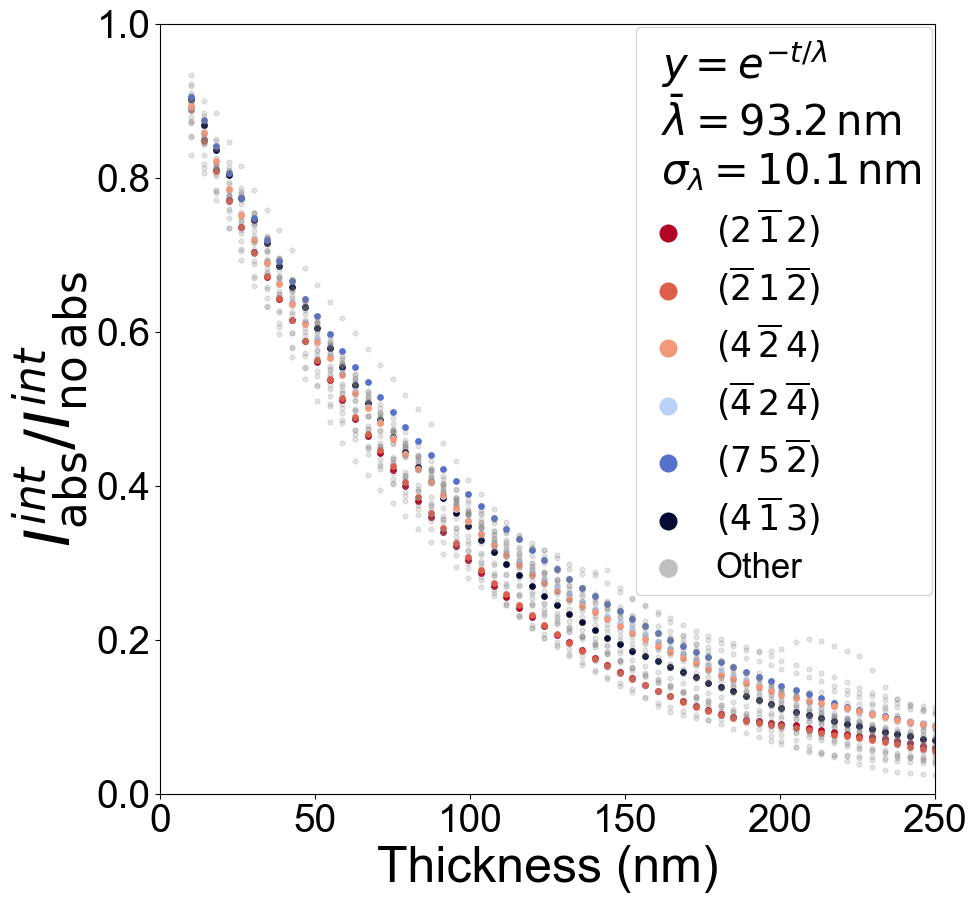


=========== ROTATION 8 ===========
HKLs fitted: 53
mean λ: 89.5755429819045
σλ: 11.083575724454068


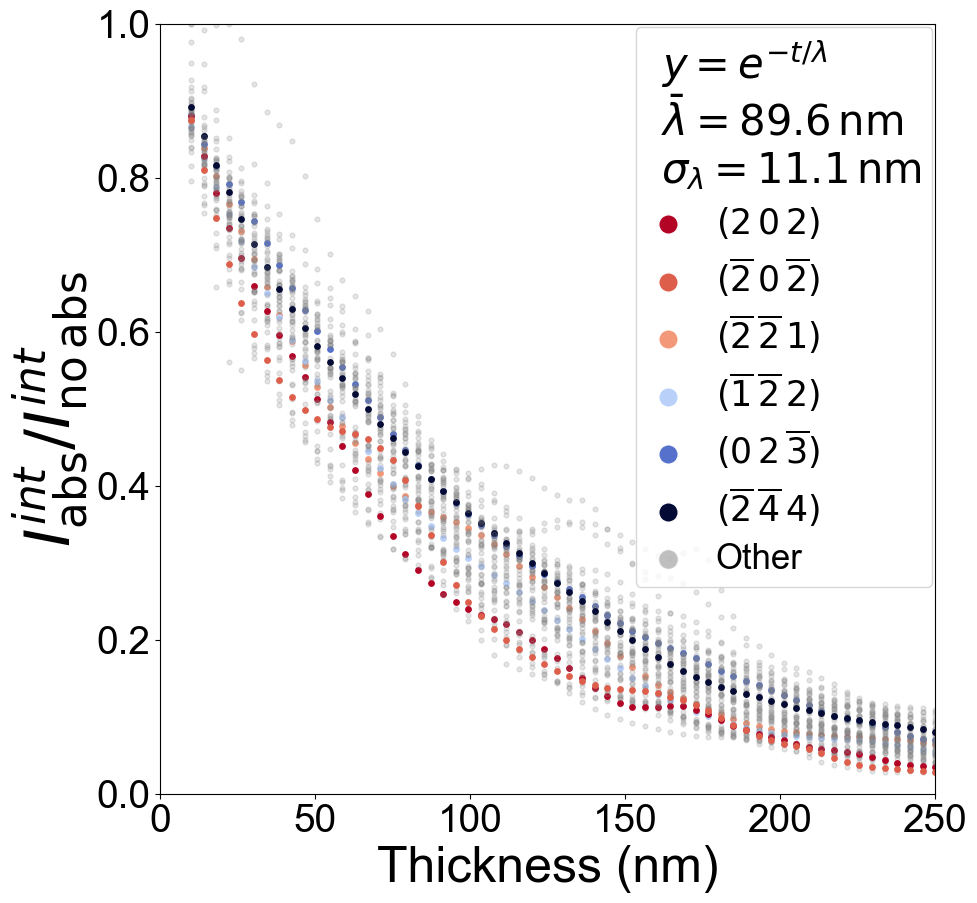


=========== ROTATION 19 ===========
HKLs fitted: 59
mean λ: 98.75888109317458
σλ: 18.17802045225063


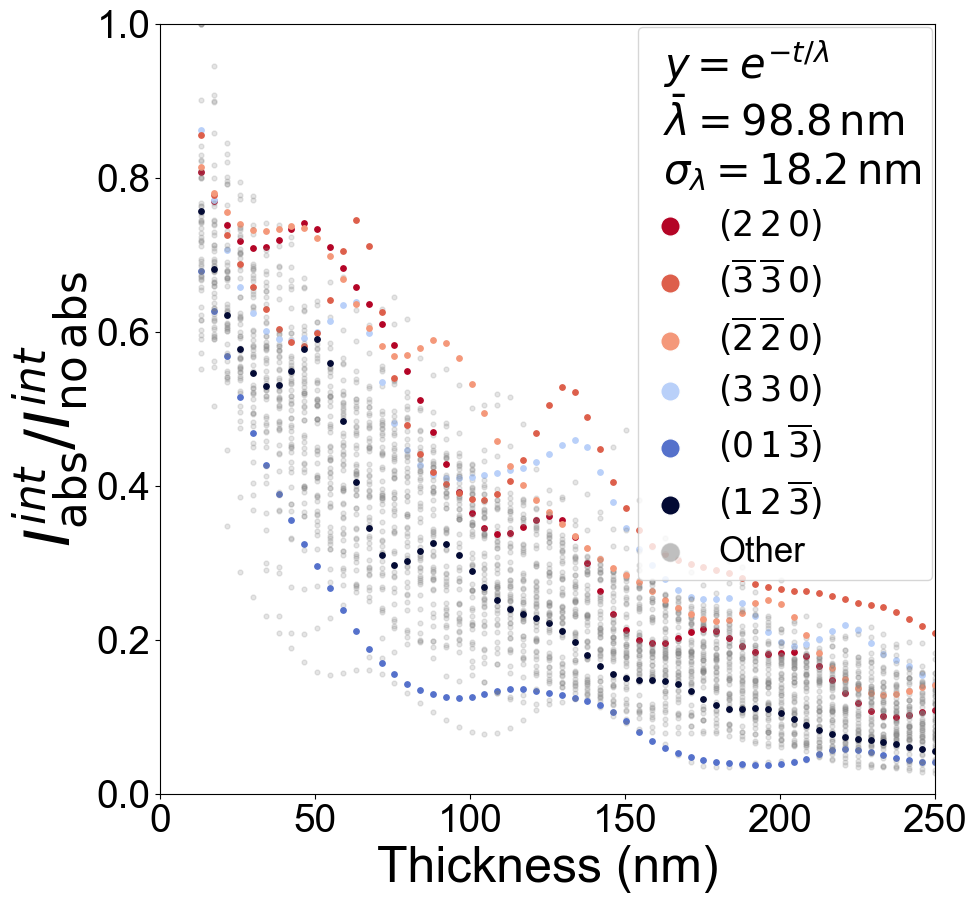

In [19]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from matplotlib.lines import Line2D
import re
from collections import defaultdict

# -----------------------------------------------------------
# FIXED CONFIG
# -----------------------------------------------------------
FOLDER = Path(str(REPO_ROOT / "absorption_paper_source_data/many_beam_simulations/cspbbr/single_run_cspbbr"))
ABS_LABEL = "param"
NONABS_LABEL = "no_abs"
CLIP_EPS = 1e-9
THICKNESS_MIN = 10.0
CIF_EXP = str(REPO_ROOT / "diffBloch_version_0.0.1/data/cspbbr3/CsPbBr_P67-crot-050_dyn.cif_pets")
ORIENTATIONS_FILTER = None

palette = ["#b40426", "#dd5f4b", "#f4987a", "#b9d0f9", "#5571cb", "#030a34"]

def format_hkl_tex(h, k, l):
    def fmt(v):
        return r"\overline{%d}" % abs(v) if v < 0 else str(v)
    return f"$({fmt(h)}\,{fmt(k)}\,{fmt(l)})$"

def parse_hkl(s):
    return tuple(int(x) for x in s.strip().split())

# -----------------------------------------------------------
# FILTER HKLs > 3σ
# -----------------------------------------------------------
def get_hkls_above_3sigma(cif_file, orientations=None):
    with open(cif_file, "r") as f:
        lines = f.readlines()

    start = None
    for i, line in enumerate(lines):
        if line.strip().startswith("loop_") and "_refln_index_h" in "".join(lines[i+1:i+12]):
            start = i
            break
    if start is None:
        return set()

    headers = []
    i = start + 1
    while lines[i].strip().startswith("_refln"):
        headers.append(lines[i].strip())
        i += 1

    rows = []
    for line in lines[i:]:
        if re.match(r"^\s*[-0-9]", line):
            rows.append(line.split())
        else:
            break

    df = pd.DataFrame(rows, columns=headers)
    df = df.apply(pd.to_numeric, errors="ignore")

    if orientations is not None and "_refln_zone_axis_id" in df.columns:
        df = df[df["_refln_zone_axis_id"].isin(np.atleast_1d(orientations))]

    mask = df["_refln_intensity_meas"] > 3 * df["_refln_intensity_sigma"]

    return {(int(h), int(k), int(l))
            for h, k, l, m in zip(df["_refln_index_h"], df["_refln_index_k"],
                                  df["_refln_index_l"], mask) if m}

HKL_FILTER = get_hkls_above_3sigma(CIF_EXP, orientations=ORIENTATIONS_FILTER)

# -----------------------------------------------------------
# MAIN PLOT FUNCTION — IDENTICAL PLOT LOGIC
# -----------------------------------------------------------
def plot_for_rotation(ROTATION):

    print(f"\n=========== ROTATION {ROTATION} ===========")

    # ----------- load files for that rotation ------------
    abs_re    = re.compile(rf"{ABS_LABEL}_rotation_{ROTATION}_thickness_([0-9.]+)_intensities\.csv$")
    nonabs_re = re.compile(rf"{NONABS_LABEL}_rotation_{ROTATION}_thickness_([0-9.]+)_intensities\.csv$")

    abs_map, nonabs_map = {}, {}

    for p in FOLDER.glob(f"{ABS_LABEL}_rotation_{ROTATION}_thickness_*_intensities.csv"):
        m = abs_re.search(p.name)
        if m:
            abs_map[float(m.group(1))] = p

    for p in FOLDER.glob(f"{NONABS_LABEL}_rotation_{ROTATION}_thickness_*_intensities.csv"):
        m = nonabs_re.search(p.name)
        if m:
            nonabs_map[float(m.group(1))] = p

    common_thicks = sorted(set(abs_map) & set(nonabs_map))
    thicknesses_nm = [t/10.0 for t in common_thicks]

    # -------- pick top-6 HKLs at ~100 nm --------
    target_idx = int(np.argmin(np.abs(np.array(thicknesses_nm) - 100)))
    tA_pick = common_thicks[target_idx]

    df_non_pick = pd.read_csv(nonabs_map[tA_pick], dtype={"HKL": str})
    top6 = df_non_pick.sort_values("Intensity", ascending=False).head(6)
    hkls_ordered = [parse_hkl(x) for x in top6["HKL"]]

    custom_colors = {h: palette[i] for i, h in enumerate(hkls_ordered)}

    # -------- compute per-HKL ratios --------
    per_hkl = defaultdict(lambda: {"t": [], "ratio": []})
    lambdas = []

    for t_A, t_nm in zip(common_thicks, thicknesses_nm):

        if t_nm < THICKNESS_MIN:
            continue

        df_abs = pd.read_csv(abs_map[t_A], dtype={"HKL": str})
        df_non = pd.read_csv(nonabs_map[t_A], dtype={"HKL": str})

        d_abs = dict(zip(df_abs["HKL"], df_abs["Intensity"]))
        d_non = dict(zip(df_non["HKL"], df_non["Intensity"]))

        for hkl_str in set(d_abs) & set(d_non):
            hkl = parse_hkl(hkl_str)
            if hkl not in HKL_FILTER:
                continue

            In = float(d_non[hkl_str])
            Ia = float(d_abs[hkl_str])
            if In <= 0:
                continue

            R = np.clip(Ia / In, CLIP_EPS, 1.0)
            per_hkl[hkl_str]["t"].append(t_nm)
            per_hkl[hkl_str]["ratio"].append(R)

    # -----------------------------------------------------------
    # PLOT — IDENTICAL TO YOUR SINGLE-PLOT VERSION
    # -----------------------------------------------------------
    plt.figure(figsize=(10, 10))

    for hkl_str, rec in per_hkl.items():
        hkl = parse_hkl(hkl_str)
        t_arr = np.array(rec["t"])
        r_arr = np.array(rec["ratio"])

        if len(t_arr) < 2:
            continue

        # ---- your λ fit ----
        log_r = np.log(r_arr)
        m, _, _, _ = np.linalg.lstsq(t_arr.reshape(-1,1), log_r, rcond=None)
        lam = -1.0 / m[0]
        lambdas.append(lam)

        if hkl in custom_colors:
            plt.scatter(t_arr, r_arr, color=custom_colors[hkl], s=15,
                        label=format_hkl_tex(*hkl))
        else:
            plt.scatter(t_arr, r_arr, color="grey", s=12, alpha=0.2)

    # ---- stats ----
    lam_mean = np.mean(lambdas)
    lam_std  = np.std(lambdas)

    stats_label = (
        r"$y = e^{-t/\lambda}$" + "\n" +
        fr"$\bar\lambda = {lam_mean:.1f}\,\mathrm{{nm}}$" + "\n" +
        fr"$\sigma_\lambda = {lam_std:.1f}\,\mathrm{{nm}}$"
    )

    legend_handles = [Line2D([0], [0], color="white", label=stats_label)]

    for hkl in hkls_ordered:
        legend_handles.append(Line2D(
            [0], [0], marker='o', color='w',
            markerfacecolor=custom_colors[hkl], markersize=14
        ))

    legend_handles.append(Line2D(
        [0], [0], marker='o', color='w',
        markerfacecolor="grey", alpha=0.5, markersize=14
    ))

    legend_labels = [stats_label] + [format_hkl_tex(*hkl) for hkl in hkls_ordered] + ["Other"]

    leg = plt.legend(
        legend_handles, legend_labels,
        fontsize=20,
        loc="upper right",
        frameon=True,
        handletextpad=-1,
        handlelength=1.5,
        borderaxespad=0.1,
       
    )

    for i, text in enumerate(leg.get_texts()):
        if i == 0:
            text.set_fontsize(30); text.set_ha("left")
        else:
            text.set_fontsize(25); text.set_ha("left"); text.set_position((55, 0))

    plt.xlabel("Thickness (nm)", fontsize=36)
    plt.ylabel(r"$I_\mathrm{abs}^{int} / I_\mathrm{no\,abs}^{int}$", fontsize=45)

    plt.xlim(0, 100)
    plt.ylim(0, 1.0)

    plt.xticks([0, 50, 100, 150, 200, 250])
    plt.yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])

    plt.tick_params(axis='both', which='major', labelsize=28)
    plt.tick_params(axis='both', which='minor', labelsize=28)

    print("HKLs fitted:", len(lambdas))
    print("mean λ:", lam_mean)
    print("σλ:", lam_std)

    plt.show()

# -----------------------------------------------------------
# CALL IT FOR THREE ORIENTATIONS
# -----------------------------------------------------------
for rot in [1, 8, 19]:
    plot_for_rotation(rot)
